# 3. Projekat iz predmeta **Mašinsko učenje**
**Dataset:**  
[Sleep Patterns vs Daily Performance](https://www.kaggle.com/datasets/zulqarnain11/sleep-patterns-vs-daily-performance/data)

U ovom projektu bavimo se problemom **regresije**, koristeći dataset o obrascima spavanja i dnevnim performansama.
Skup podataka sadrži informacije o navikama spavanja i svakodnevnim faktorima koji utiču na produktivnost, na osnovu kojih se predviđa numerička vrednost produktivnosti.

## Osobine (feature-i)
- **Sleep_Hours** - broj sati sna
- **Sleep_Quality_Score** - ocena kvaliteta sna
- **Energy_Level** - nivo energije tokom dana
- **Caffeine_Intake_mg** - unos kofeina u miligramima
- **Screen_Time_Before_Bed** - vreme provedeno ispred ekrana pre spavanja
- **Error_Rate** - stopa grešaka pri radu
- **Morning_Mood** - raspoloženje ujutru (ordinalna kategorička promenljiva: Very Bad → Bad → Neutral → Good → Excellent)

## Setup i učitavanje
### Import biblioteka i setovanje konstantni

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

### Učitavanje podataka i pregled strukture

In [2]:
dataset = pd.read_csv('Sleep_Patterns_vs_Daily_Performance.csv')

dataset.info()
dataset.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Sleep_Hours              30000 non-null  float64
 1   Sleep_Quality_Score      30000 non-null  int64  
 2   Caffeine_Intake_mg       30000 non-null  float64
 3   Screen_Time_Before_Bed   30000 non-null  float64
 4   Morning_Mood             30000 non-null  object 
 5   Work_Productivity_Score  30000 non-null  int64  
 6   Error_Rate               30000 non-null  float64
 7   Energy_Level             30000 non-null  int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 1.8+ MB


,Sleep_Hours,Sleep_Quality_Score,Caffeine_Intake_mg,Screen_Time_Before_Bed,Work_Productivity_Score,Error_Rate,Energy_Level
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,6.987010,7.590433,198.492067,58.685500,73.637667,6.499266,8.656567
std,1.468244,1.518826,133.939111,54.993704,13.119905,3.785921,1.330669
min,2.000000,1.000000,1.000000,0.000000,6.000000,0.000000,1.000000
25%,6.000000,7.000000,97.000000,17.000000,66.000000,3.757500,8.000000
50%,7.000000,8.000000,169.000000,42.000000,75.000000,6.140000,9.000000
75%,8.000000,9.000000,271.000000,84.000000,83.000000,8.890000,10.000000
max,10.000000,10.000000,600.000000,240.000000,100.000000,26.900000,10.000000


In [3]:
dataset.head()

,Sleep_Hours,Sleep_Quality_Score,Caffeine_Intake_mg,Screen_Time_Before_Bed,Morning_Mood,Work_Productivity_Score,Error_Rate,Energy_Level
0,7.7,7,498.0,107.0,Neutral,71,10.45,8
1,6.8,8,315.0,128.0,Good,80,6.49,10
2,8.0,10,412.0,34.0,Excellent,85,3.88,10
3,9.3,9,447.0,28.0,Good,85,3.18,10
4,6.6,7,177.0,57.0,Neutral,70,6.74,8


## Preprocesiranje podataka

### Uklanjanje duplikata

In [4]:
broj_duplikata = dataset.duplicated().sum()
print(f'Broj duplikata: {broj_duplikata}')

Broj duplikata: 0


### Analiza podataka

#### Analiza nedostajućih vrednosti

In [5]:
dataset.isnull().sum()

Sleep_Hours                0
Sleep_Quality_Score        0
Caffeine_Intake_mg         0
Screen_Time_Before_Bed     0
Morning_Mood               0
Work_Productivity_Score    0
Error_Rate                 0
Energy_Level               0
dtype: int64

### Preprocesiranje kolone <b>Morning_Mood</b>

Kolona <i>Morning_Mood</i> je ordinalna kategorička promenljiva sa prirodnim redosledom:
<i>Very Bad → Bad → Neutral → Good → Excellent</i>

Odrađeno je ordinalno enkodiranje koje čuva ovaj redosled, za razliku od One-Hot Encodinga koji bi
tretirao klase kao nezavisne.

In [6]:
mood_order = ['Very Bad', 'Bad', 'Neutral', 'Good', 'Excellent']
mood_map   = {m: i for i, m in enumerate(mood_order)}

dataset['Morning_Mood'] = dataset['Morning_Mood'].map(mood_map)

print('Mapiranje Morning_Mood:')
for k, v in mood_map.items():
    print(f'  {v} -> {k}')
print()

Mapiranje Morning_Mood:
  0 -> Very Bad
  1 -> Bad
  2 -> Neutral
  3 -> Good
  4 -> Excellent



## EDA

#### Distribucija targeta <i>Work_Productivity_Score</i>

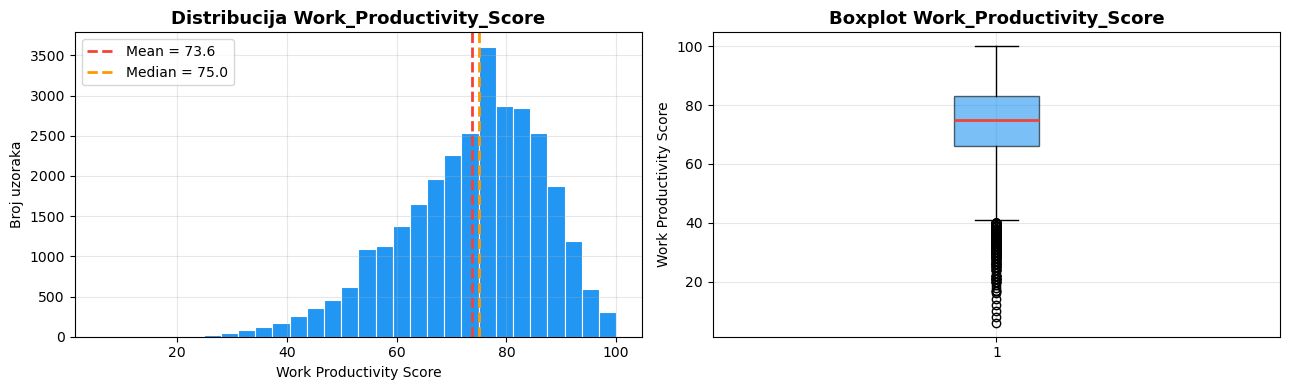

Min:    6
Max:    100
Mean:   73.64
Median: 75.00
Std:    13.12


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(dataset['Work_Productivity_Score'], bins=30,
             color='#2196F3', edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribucija Work_Productivity_Score', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Work Productivity Score')
axes[0].set_ylabel('Broj uzoraka')
axes[0].axvline(dataset['Work_Productivity_Score'].mean(), color='#F44336',
                linewidth=2, linestyle='--', label=f'Mean = {dataset["Work_Productivity_Score"].mean():.1f}')
axes[0].axvline(dataset['Work_Productivity_Score'].median(), color='#FF9800',
                linewidth=2, linestyle='--', label=f'Median = {dataset["Work_Productivity_Score"].median():.1f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(dataset['Work_Productivity_Score'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#2196F3', alpha=0.6),
                medianprops=dict(color='#F44336', linewidth=2))
axes[1].set_title('Boxplot Work_Productivity_Score', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Work Productivity Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Min:    {dataset["Work_Productivity_Score"].min():.0f}')
print(f'Max:    {dataset["Work_Productivity_Score"].max():.0f}')
print(f'Mean:   {dataset["Work_Productivity_Score"].mean():.2f}')
print(f'Median: {dataset["Work_Productivity_Score"].median():.2f}')
print(f'Std:    {dataset["Work_Productivity_Score"].std():.2f}')

Zapažanja:

Distribucija je negativno asimetrična: Većina ljudi ima visoku produktinost sa relativno malo neproduktivnih dana.

Boxplot pokazuje da se outlieri pojavljuju samo u donjoj granici (ispod 40) i predstavljaju ekstremno niske vrednosti.

### Korelaciona matrica feature-a

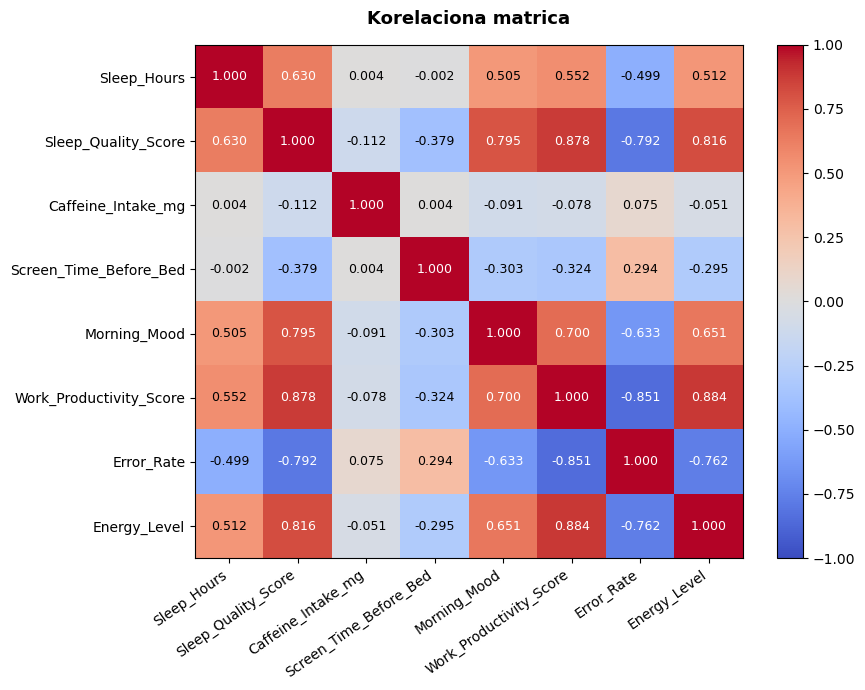

Korelacija sa Work_Productivity_Score (sortirano):
Energy_Level              0.884053
Sleep_Quality_Score       0.877801
Morning_Mood              0.700160
Sleep_Hours               0.552399
Caffeine_Intake_mg       -0.077774
Screen_Time_Before_Bed   -0.323615
Error_Rate               -0.851021


In [8]:
corr = dataset.corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')

labels = corr.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=10)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_title('Korelaciona matrica', fontsize=13, fontweight='bold', pad=15)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr.values[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9, color=color)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print('Korelacija sa Work_Productivity_Score (sortirano):')
print(corr['Work_Productivity_Score'].drop('Work_Productivity_Score').sort_values(ascending=False).to_string())

Zapažanja:

- Najjači prediktori produktivnosti su `Energy_Level` (r = 0.884), `Sleep_Quality_Score`(r = 0.878) i `Error_Rate` (r = -0.851), dok `Caffeine_Intake_mg` (r = -0.078).
- Postoji multikolinearnost između `Sleep_Quality_Score`, `Energy_Level`, `Error_Rate` i `Morning_Mood`.


### VIF analiza za multikolinearnost

Feature                           VIF  Interpretacija
------------------------------------------------------------
Sleep_Quality_Score            156.69  ⚠ Ozbiljan problem
Energy_Level                   102.48  ⚠ Ozbiljan problem
Sleep_Hours                     44.45  ⚠ Ozbiljan problem
Morning_Mood                    27.40  ⚠ Ozbiljan problem
Error_Rate                       3.80    Umerena kolinearnost
Caffeine_Intake_mg               3.25    Umerena kolinearnost
Screen_Time_Before_Bed           2.71    Umerena kolinearnost


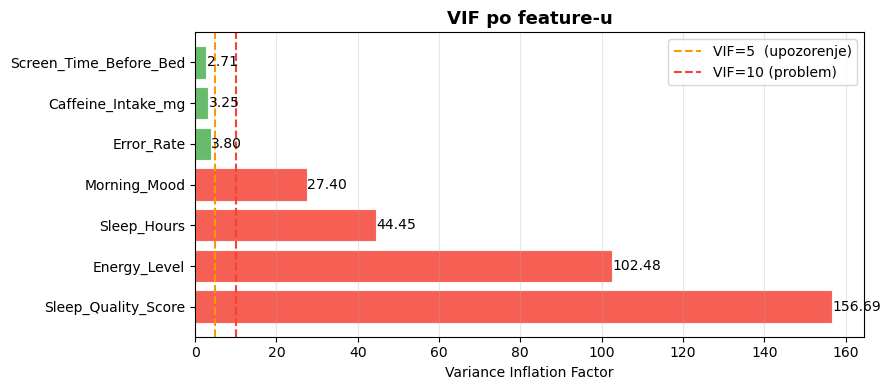

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
 
feature_cols = ['Sleep_Hours', 'Sleep_Quality_Score', 'Caffeine_Intake_mg',
                'Screen_Time_Before_Bed', 'Morning_Mood', 'Error_Rate', 'Energy_Level']
 
X_vif = dataset[feature_cols].astype(float)
 
vif_data = pd.DataFrame({
    'Feature': feature_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)
 
print(f"{'Feature':<28} {'VIF':>8}  {'Interpretacija'}")
print('-' * 60)
for _, row in vif_data.iterrows():
    if row['VIF'] > 10:
        interp = '⚠ Ozbiljan problem'
    elif row['VIF'] > 5:
        interp = '⚠ Visoka kolinearnost'
    elif row['VIF'] > 2:
        interp = '  Umerena kolinearnost'
    else:
        interp = '  Prihvatljivo'
    print(f"{row['Feature']:<28} {row['VIF']:>8.2f}  {interp}")
 
fig, ax = plt.subplots(figsize=(9, 4))
colors_vif = ['#F44336' if v > 10 else '#FF9800' if v > 5 else '#4CAF50'
              for v in vif_data['VIF']]
bars = ax.barh(vif_data['Feature'], vif_data['VIF'],
               color=colors_vif, edgecolor='white', linewidth=0.8, alpha=0.85)
ax.axvline(x=5,  color='#FF9800', linestyle='--', linewidth=1.5, label='VIF=5  (upozorenje)')
ax.axvline(x=10, color='#F44336', linestyle='--', linewidth=1.5, label='VIF=10 (problem)')
ax.set_title('VIF po feature-u', fontsize=13, fontweight='bold')
ax.set_xlabel('Variance Inflation Factor')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, vif_data['VIF']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

Zapažanja:

VIF analiza potvrđuje multikolinearnost gde su najproblematičniji fičeri `Sleep_Quality_Score`i `Energy_Level`(mogu da se rekonstruišu iz kombinacije ostalih fičera) - Potencijalno mogu da se izbace i da se trenira model sa 5 fičera.


### PCA analiza za multikolineranost

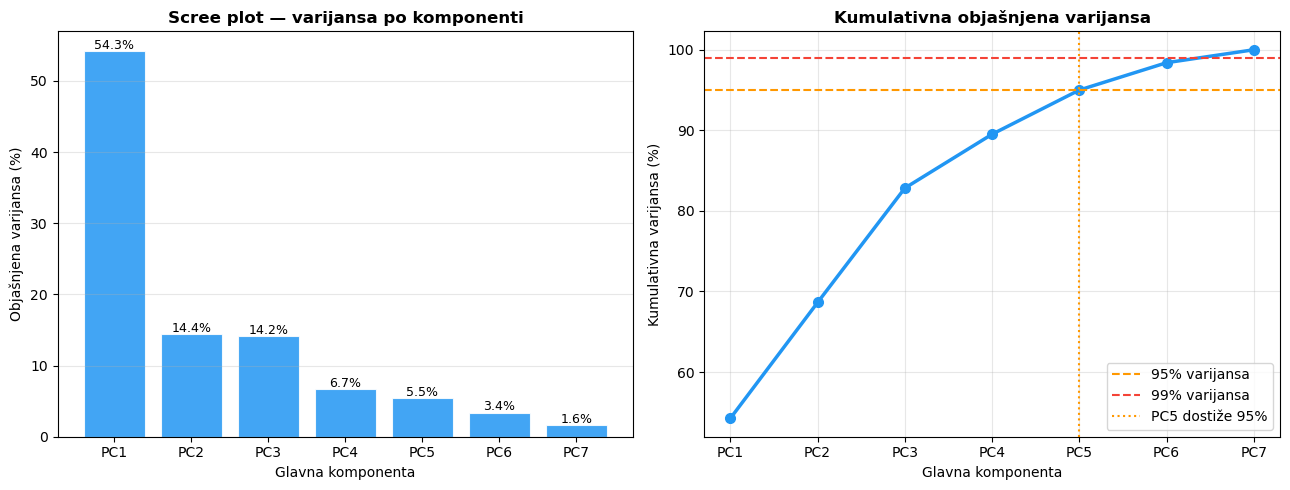

In [10]:
from sklearn.decomposition import PCA
 
feature_cols = ['Sleep_Hours', 'Sleep_Quality_Score', 'Caffeine_Intake_mg',
                'Screen_Time_Before_Bed', 'Morning_Mood', 'Error_Rate', 'Energy_Level']
 
X_raw = dataset[feature_cols].astype(float).values
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X_raw)
 
pca_full = PCA()
pca_full.fit(X_scaled_pca)
 
explained      = pca_full.explained_variance_ratio_
cumulative     = np.cumsum(explained)
n_95           = np.argmax(cumulative >= 0.95) + 1
n_99           = np.argmax(cumulative >= 0.99) + 1
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pc_labels = [f'PC{i+1}' for i in range(len(explained))]
 
axes[0].bar(pc_labels, explained * 100, color='#2196F3',
            edgecolor='white', linewidth=0.8, alpha=0.85)
axes[0].set_title('Scree plot — varijansa po komponenti',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Glavna komponenta')
axes[0].set_ylabel('Objašnjena varijansa (%)')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(explained * 100):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)
 
axes[1].plot(pc_labels, cumulative * 100,
             color='#2196F3', linewidth=2.5, marker='o', markersize=7)
axes[1].axhline(y=95, color='#FF9800', linestyle='--',
                linewidth=1.5, label='95% varijansa')
axes[1].axhline(y=99, color='#F44336', linestyle='--',
                linewidth=1.5, label='99% varijansa')
axes[1].axvline(x=n_95-1, color='#FF9800', linestyle=':',
                linewidth=1.5, label=f'PC{n_95} dostiže 95%')
axes[1].set_title('Kumulativna objašnjena varijansa',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Glavna komponenta')
axes[1].set_ylabel('Kumulativna varijansa (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Zapažanje:

- Postoji dominantna komponenta(objašnjava 54.3% ukupne varijanse)
- Redukacija sa 7 na 5 komponenti nosi ukupno 95% varijanse
- Za ukupno 99% varijanse potrebno je svih 7 komponenti - svaka nosi neku jedinstvenu informaciju

### PCA Loadings Heatmapa

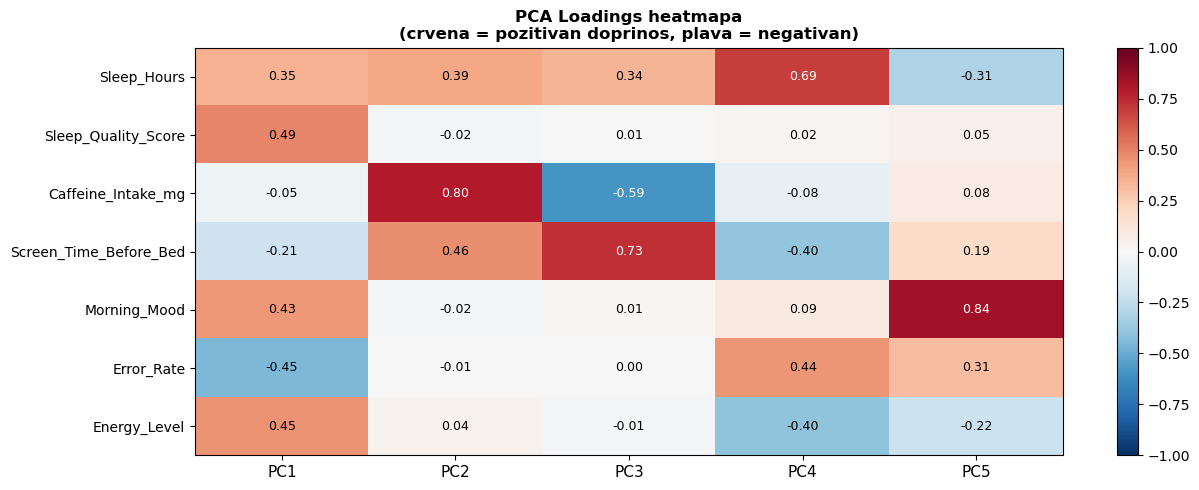

In [11]:
pca_show = PCA(n_components=n_95)
pca_show.fit(X_scaled_pca)
 
loadings = pd.DataFrame(
    pca_show.components_.T,
    index=feature_cols,
    columns=[f'PC{i+1}' for i in range(n_95)]
)
 
fig, ax = plt.subplots(figsize=(n_95 * 2 + 3, 5))
im = ax.imshow(loadings.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(n_95))
ax.set_xticklabels([f'PC{i+1}' for i in range(n_95)], fontsize=11)
ax.set_yticks(range(len(feature_cols)))
ax.set_yticklabels(feature_cols, fontsize=10)
ax.set_title('PCA Loadings heatmapa\n(crvena = pozitivan doprinos, plava = negativan)',
             fontsize=12, fontweight='bold')
for i in range(len(feature_cols)):
    for j in range(n_95):
        val = loadings.values[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

Zapažanje:
- <b>PC1 (54% varijanse)</b> - faktor kvaliteta odmora i produktivnosti
    - Osoba koja dobro spava ima energije, dbro je raspoložena i manje greši.

- <b>PC2 (14% varijanse)</b> - faktor stimulansa
    - kofein i vreme provedeno uz ekran su spoljni stimulansi koji su međusobno slabo korelisani sa snom i produktivnošću, ali mogu biti korelisani međusobno 

- <b>PC3 (14% varijanse)</b> - kontrast kofeina i vreme provedeno uz ekran
    - hvata razliku osoba koje konzumiraju kofein a ne provode dosta vremena uz ekran i obrnuto

- <b>PC4 (6.7% varijanse)</b> - faktor sati sna nezavisno od kvaliteta
    - hvata situaciju gde neko spava dugo ali ne nužno kvalitetno

- <b>PC5 (5.5% varijanse) </b> - faktor raspoloženja nezavisno od sna
    - hvata varijabilnost raspoloženja koja nije objašnjena kvalitetom sna - možda stres, lični faktori, itd.

#### Scatter plot - Feature-i vs <i>Work_Productivity_Score</i>

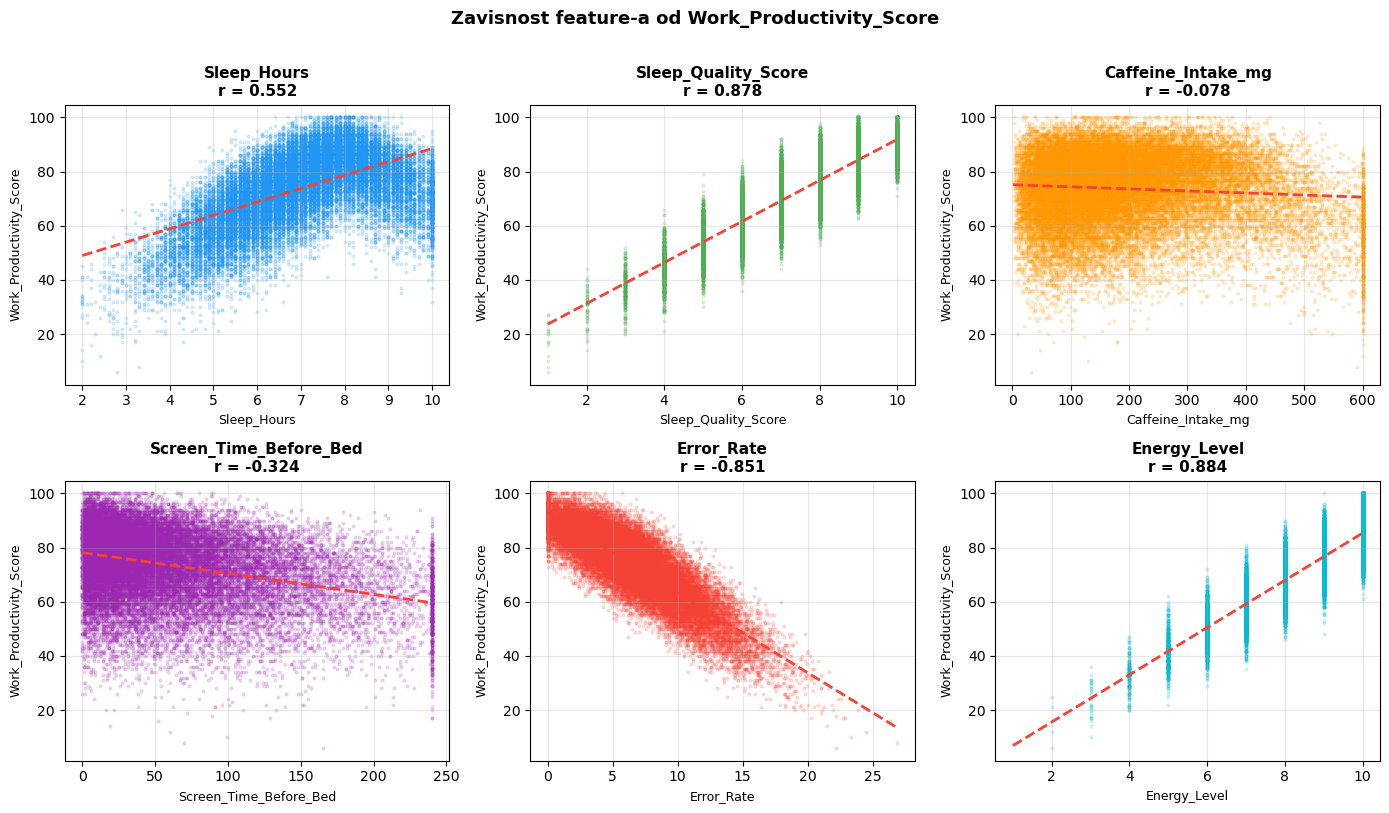

In [12]:
num_features = ['Sleep_Hours', 'Sleep_Quality_Score', 'Caffeine_Intake_mg',
                'Screen_Time_Before_Bed', 'Error_Rate', 'Energy_Level']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
colors_scatter = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#00BCD4']

for i, col in enumerate(num_features):
    r = dataset[col].corr(dataset['Work_Productivity_Score'])
    axes[i].scatter(dataset[col], dataset['Work_Productivity_Score'],
                    alpha=0.15, s=4, color=colors_scatter[i])
    z = np.polyfit(dataset[col], dataset['Work_Productivity_Score'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(dataset[col].min(), dataset[col].max(), 100)
    axes[i].plot(x_line, p(x_line), color='#F44336', linewidth=2, linestyle='--')
    axes[i].set_title(f'{col}\nr = {r:.3f}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('Work_Productivity_Score', fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Zavisnost feature-a od Work_Productivity_Score',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Zapažanja:

- Sleep Hours
    - umerena, blago nelinearna zavisnost
    - sa više od 8 sati sna produktivnost prestaje da raste 

- Sleep Quality Score i Energy Level
    - prikazuju gotovo identično ponašanje - linearna zavisnost
    - sa povećanjem kvaliteta sna/ nivoom energije se povećava i produktivnost

- Caffeine Intake in miligrams
    - horizontalna trend linija 
    - tačke su ravnomerno raspoređene celom dužinom
    - koefin gotovo uopšte ne predviđa produktivnost

- Screen Time Before Bed
    - slabo negativna veza
    - veza postoji ali je jako slaba i nije pouzdana za predikciju

- Error Rate
    -  linearna negativna veza
    - sa porastom broja grešaka produktivnost pada

#### <i>Morning_Mood</i> vs <i>Work_Productivity_Score</i>

/var/folders/r8/ld1vjw5x7sj5mk7hfs3q28sr0000gn/T/ipykernel_24082/3239374769.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(mood_groups, labels=mood_labels, patch_artist=True,


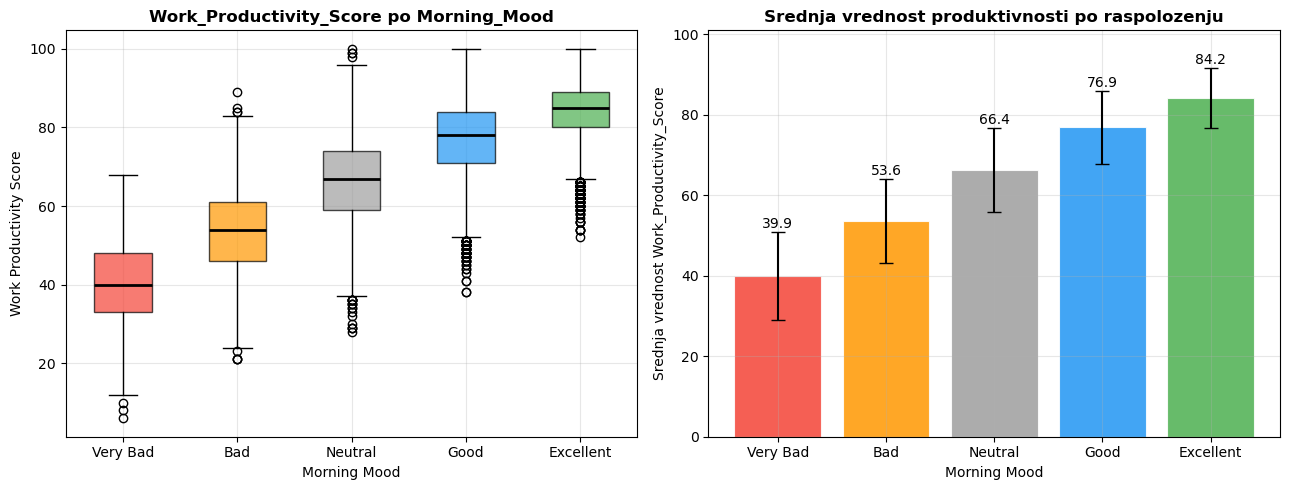

In [13]:
mood_labels = ['Very Bad', 'Bad', 'Neutral', 'Good', 'Excellent']
colors_mood = ['#F44336', '#FF9800', '#9E9E9E', '#2196F3', '#4CAF50']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mood_groups = [dataset[dataset['Morning_Mood'] == i]['Work_Productivity_Score']
               for i in range(5)]
bp = axes[0].boxplot(mood_groups, labels=mood_labels, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors_mood):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Work_Productivity_Score po Morning_Mood', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Morning Mood')
axes[0].set_ylabel('Work Productivity Score')
axes[0].grid(True, alpha=0.3)

means = [g.mean() for g in mood_groups]
stds  = [g.std() for g in mood_groups]
axes[1].bar(mood_labels, means, color=colors_mood, edgecolor='white',
            linewidth=0.8, alpha=0.85, yerr=stds, capsize=5)
axes[1].set_title('Srednja vrednost produktivnosti po raspolozenju', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Morning Mood')
axes[1].set_ylabel('Srednja vrednost Work_Productivity_Score')
for i, (m, s) in enumerate(zip(means, stds)):
    axes[1].text(i, m + s + 1, f'{m:.1f}', ha='center', fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, max(means) * 1.2)

plt.tight_layout()
plt.show()

Zapažanje:

- Grafik pokazuje jasnu i monotonu vezu između jutarnjeg raspoloženja i produktivnosti.
- Postoje outlieri u donjoj granici u svakoj kategoriji, i outlieri u gronjoj granici kod `Bad` i `Neutral` jutarnjeg raspoloženja.
- Ima dosta rasipanja (osoba sa `Good` jutarnjim raspoloženjem može imati istu produktivnost kao neko sa `Very Bad` jutarnjim raspoloženjem) - fičer nije dovoljno jak prediktor 

#### Heatmapa: Uticaj kvaliteta i dužine sna na produktivnost

/var/folders/r8/ld1vjw5x7sj5mk7hfs3q28sr0000gn/T/ipykernel_24082/2373501981.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = dataset.pivot_table(


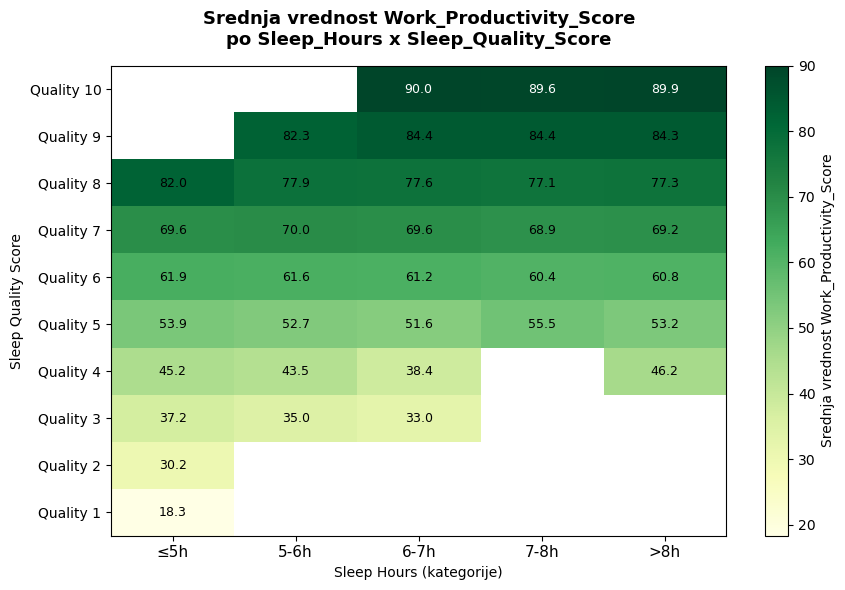

In [14]:
dataset['sleep_bin'] = pd.cut(dataset['Sleep_Hours'],
                               bins=[1.9, 5, 6, 7, 8, 10.1],
                               labels=['≤5h', '5-6h', '6-7h', '7-8h', '>8h'])

pivot = dataset.pivot_table(
    values='Work_Productivity_Score',
    index='Sleep_Quality_Score',
    columns='sleep_bin',
    aggfunc='mean'
)
pivot = pivot.sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(pivot.values, cmap='YlGn', aspect='auto',
               vmin=pivot.values[~np.isnan(pivot.values)].min(),
               vmax=pivot.values[~np.isnan(pivot.values)].max())

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=11)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'Quality {v}' for v in pivot.index], fontsize=10)
ax.set_title('Srednja vrednost Work_Productivity_Score\npo Sleep_Hours x Sleep_Quality_Score',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Sleep Hours (kategorije)')
ax.set_ylabel('Sleep Quality Score')

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=9,
                    color='black' if val < 85 else 'white')

plt.colorbar(im, ax=ax, label='Srednja vrednost Work_Productivity_Score')
plt.tight_layout()
plt.show()

dataset = dataset.drop(columns=['sleep_bin'])

Zapažanja:

- Kvalitet sna dominantno određuje produktivnost dok broj sati sna ne doprinosi puno.
- Vrednosti za redove Q7-Q10 su jako slične kroz sve kategorije trajanja sna
- Prazne ćelije gore levo i dole desno - osobe koje spavaju kratko retko imaju visok kvalitet sna, i osobe koje spavaju duge retko imaju loš kvalitet sna
- Q8 pokazuje najveću vrednost u kategoriji <= 5 

#### Distribucija svih feature-a

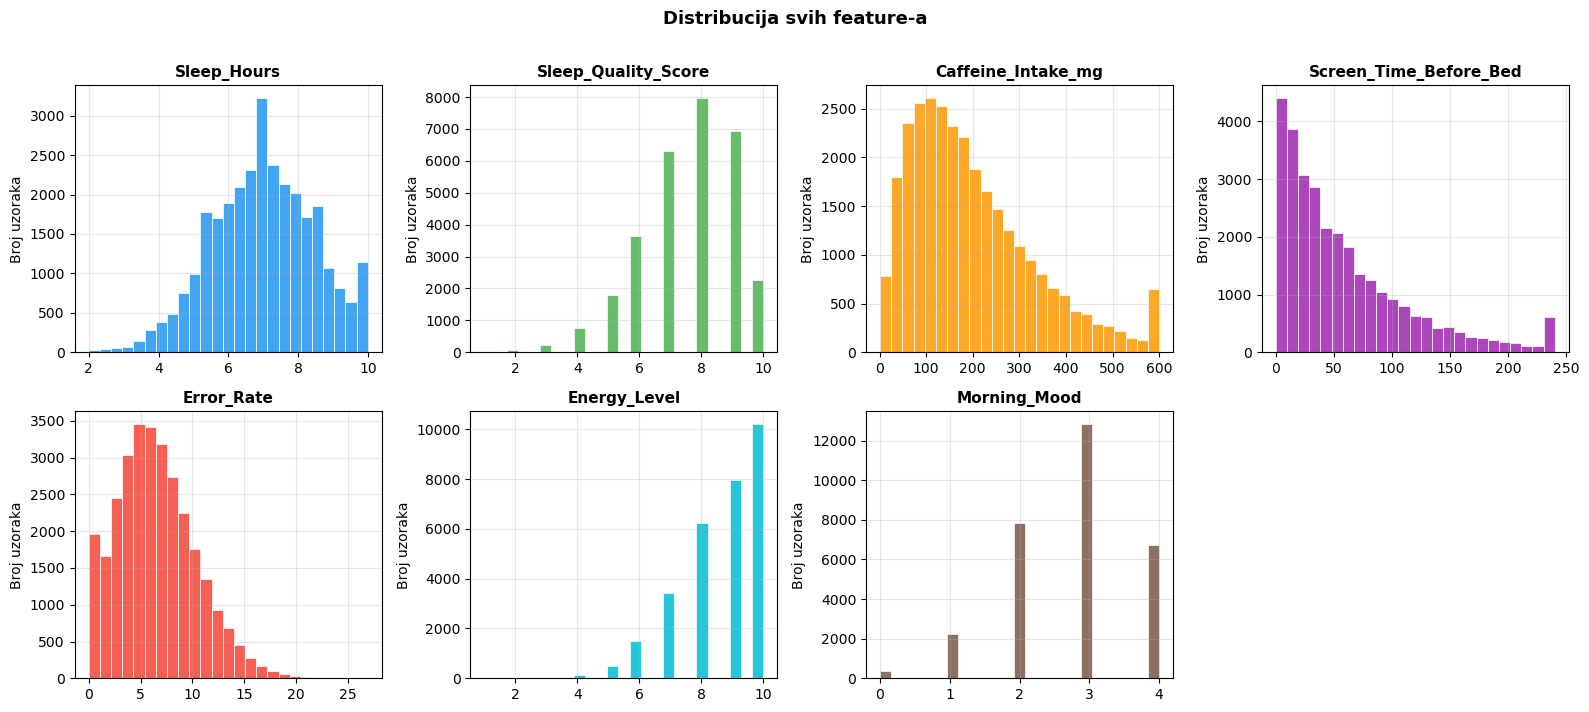

In [15]:
all_features = ['Sleep_Hours', 'Sleep_Quality_Score', 'Caffeine_Intake_mg',
                'Screen_Time_Before_Bed', 'Error_Rate', 'Energy_Level',
                'Morning_Mood']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
palette = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4','#795548','#607D8B']

for i, col in enumerate(all_features):
    axes[i].hist(dataset[col], bins=25, color=palette[i],
                 edgecolor='white', linewidth=0.6, alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Broj uzoraka')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_visible(False)

plt.suptitle('Distribucija svih feature-a', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Zapažanja: 
- `Sleep Quality Score`, `Morning Mood` `Energy Level` su sa pravilnim stepenastim oblikom
- `Sleep Hours` i `Error Rate` imaju približno normalnu simetričnu distribuciju
- `Coffeine Intake` i `Screen Time Before Bed` imaju pozitivnu asimetričnu distribuciju

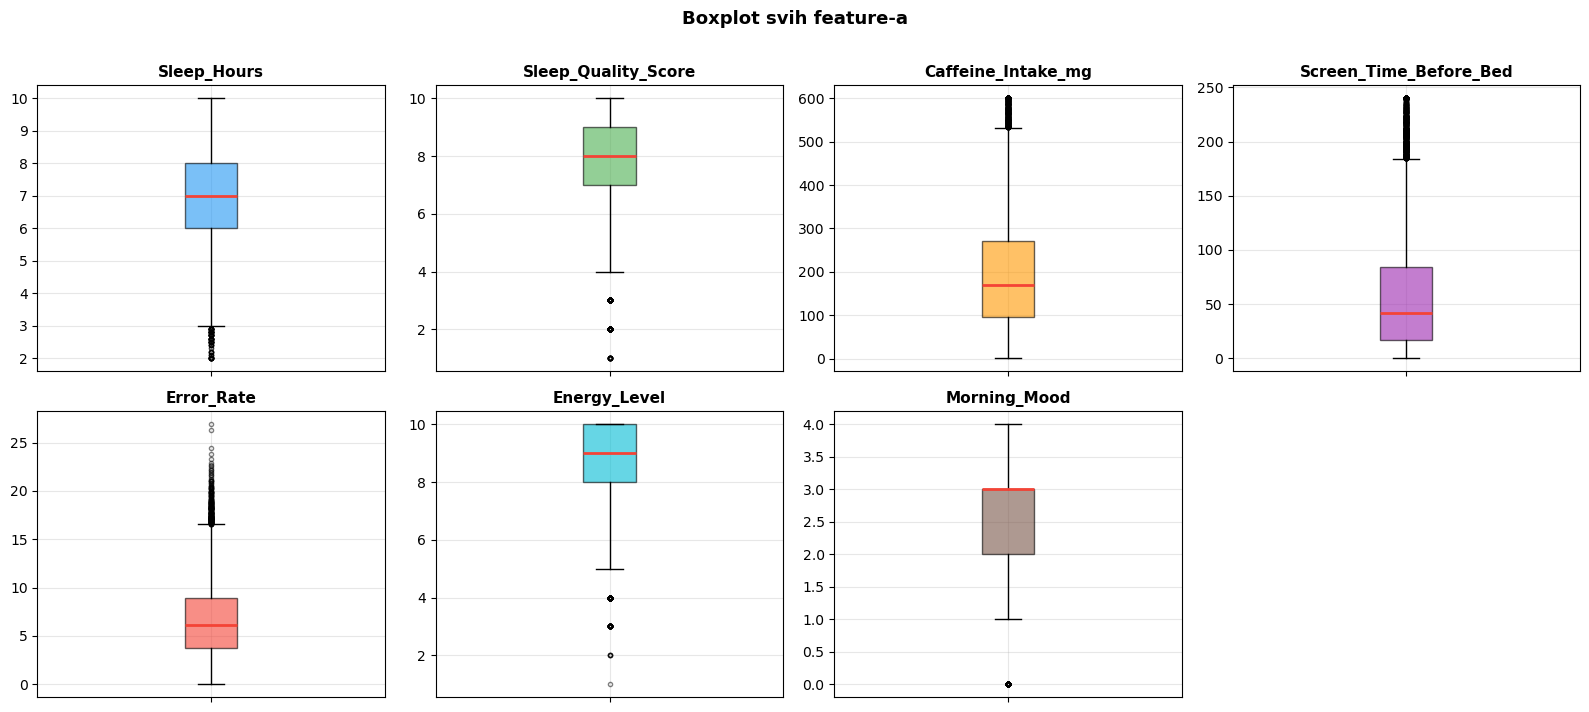

In [16]:
all_features = ['Sleep_Hours', 'Sleep_Quality_Score', 'Caffeine_Intake_mg',
                'Screen_Time_Before_Bed', 'Error_Rate', 'Energy_Level',
                'Morning_Mood']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
palette = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4','#795548']

for i, col in enumerate(all_features):
    bp = axes[i].boxplot(dataset[col], vert=True, patch_artist=True,
                         boxprops=dict(facecolor=palette[i], alpha=0.6),
                         medianprops=dict(color='#F44336', linewidth=2),
                         flierprops=dict(marker='o', markersize=3, alpha=0.5))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xticklabels([])
    axes[i].grid(True, alpha=0.3)

axes[-1].set_visible(False)

plt.suptitle('Boxplot svih feature-a', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Zapažanje: Sve kolone poseduju outlier-e

## Analiza i obrada outliera
Korišćena je IQR metoda zbog asimetrične distribucije samo nad kolonama koje nemaju diskretne vrednosti (svaki outlier je ovde validna kategorija)

In [17]:
cols_to_check = ['Work_Productivity_Score', 'Caffeine_Intake_mg', 'Screen_Time_Before_Bed', 'Error_Rate', 'Sleep_Hours']

print(f'{"Kolona":<28} {"Q1":>7} {"Q3":>7} {"IQR":>7} {"Outlieri":>10} {"Procenat":>10}')
print('-' * 75)
for col in cols_to_check:
    Q1  = dataset[col].quantile(0.25)
    Q3  = dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    mask = (dataset[col] < Q1 - 1.5 * IQR) | (dataset[col] > Q3 + 1.5 * IQR)
    n_out = mask.sum()
    print(f'{col:<28} {Q1:>7.1f} {Q3:>7.1f} {IQR:>7.1f} {n_out:>10} {n_out/len(dataset)*100:>9.2f}%')

print()

Kolona                            Q1      Q3     IQR   Outlieri   Procenat
---------------------------------------------------------------------------
Work_Productivity_Score         66.0    83.0    17.0        482      1.61%
Caffeine_Intake_mg              97.0   271.0   174.0        896      2.99%
Screen_Time_Before_Bed          17.0    84.0    67.0       1343      4.48%
Error_Rate                       3.8     8.9     5.1        288      0.96%
Sleep_Hours                      6.0     8.0     2.0        117      0.39%



#### Odluka:
Outlieri se <b>ne uklanjaju</b> jer:
- Predstavljaju realne vrednosti (npr. 600mg kofeina dnevno je ekstremno ali moguće)
- Procenat outliera je mali (< 5% po koloni)

### Podela dataseta na Train/Validation/Test

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = dataset.drop(columns=['Work_Productivity_Score']).astype(float).values
y = dataset['Work_Productivity_Score'].values.astype(float)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Train:      {X_train_s.shape[0]:,} uzoraka")
print(f"Validation: {X_val_s.shape[0]:,} uzoraka")
print(f"Test:       {X_test_s.shape[0]:,} uzoraka")

Train:      21,000 uzoraka
Validation: 4,500 uzoraka
Test:       4,500 uzoraka


### Baseline Mean Predictor

In [19]:
y_mean_pred = np.full_like(y_test, fill_value=y_train.mean())

mae_baseline  = mean_absolute_error(y_test, y_mean_pred)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_mean_pred))
r2_baseline   = r2_score(y_test, y_mean_pred)

print(f"  MAE:  {mae_baseline:.4f}")
print(f"  RMSE: {rmse_baseline:.4f}")
print(f"  R²:   {r2_baseline:.4f}")
print()
print(f"Uvek predviđa: {y_train.mean():.2f}")

  MAE:  10.3249
  RMSE: 12.9558
  R²:   -0.0001

Uvek predviđa: 73.67


## Baseline neuronska mreža

In [20]:
def build_baseline_model(input_dim):
    inputs = keras.Input(shape=(input_dim,), name="input")

    x = layers.Dense(64, activation='relu', name="dense_1")(inputs)
    x = layers.Dense(32, activation='relu', name="dense_2")(x)

    outputs = layers.Dense(1, name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs,
                        name="Baseline_SleepNet")
    return model

baseline_model = build_baseline_model(input_dim=X_train_s.shape[1])

summary_data = []
for layer in baseline_model.layers:
    summary_data.append({
        'Sloj': layer.name,
        'Tip': layer.__class__.__name__,
        'Izlazni oblik': str(layer.output.shape),
        'Parametri': layer.count_params()
    })

summary_df = pd.DataFrame(summary_data)
total = baseline_model.count_params()
trainable = sum(w.numpy().size for w in baseline_model.trainable_weights)
summary_df.loc[len(summary_df)] = ['UKUPNO', '', '', total]

print(f'Model: "{baseline_model.name}"')
summary_df

Model: "Baseline_SleepNet"


,Sloj,Tip,Izlazni oblik,Parametri
0,input,InputLayer,"(None, 7)",0
1,dense_1,Dense,"(None, 64)",512
2,dense_2,Dense,"(None, 32)",2080
3,output,Dense,"(None, 1)",33
4,UKUPNO,,,2625


In [21]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',
    metrics=['mae']
)

In [22]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

In [23]:
history = baseline_model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,
    batch_size=256,
    callbacks=callbacks,
    verbose=0
)


Epoch 89: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Restoring model weights from the end of the best epoch: 100.


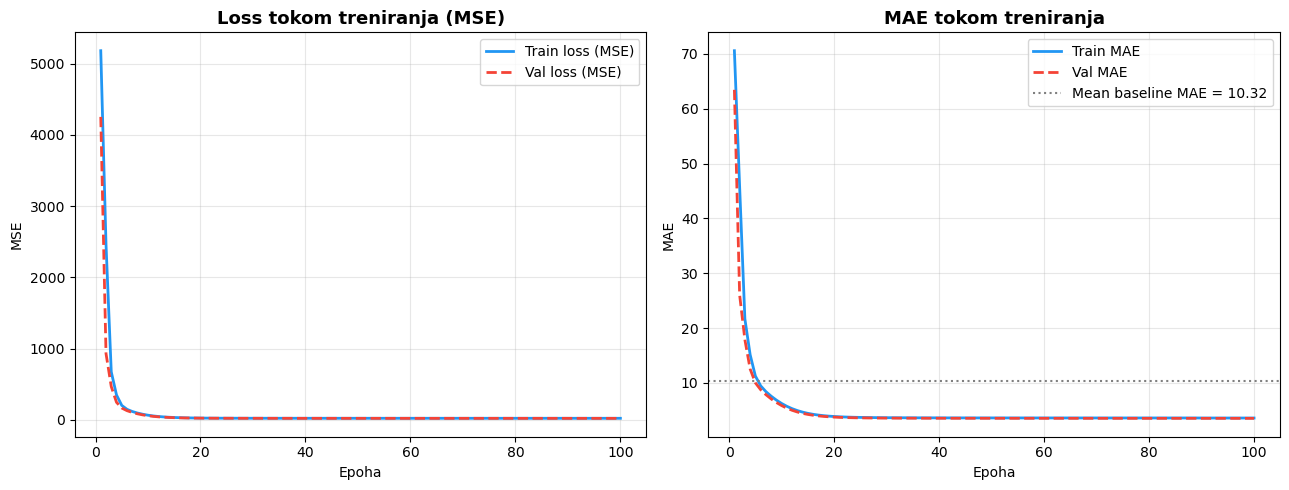

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, len(history.history['loss']) + 1)

axes[0].plot(epochs_range, history.history['loss'],
             label='Train loss (MSE)', color='#2196F3', linewidth=2)
axes[0].plot(epochs_range, history.history['val_loss'],
             label='Val loss (MSE)', color='#F44336', linewidth=2, linestyle='--')
axes[0].set_title('Loss tokom treniranja (MSE)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history.history['mae'],
             label='Train MAE', color='#2196F3', linewidth=2)
axes[1].plot(epochs_range, history.history['val_mae'],
             label='Val MAE', color='#F44336', linewidth=2, linestyle='--')
axes[1].axhline(y=mae_baseline, color='gray', linestyle=':',
                linewidth=1.5, label=f'Mean baseline MAE = {mae_baseline:.2f}')
axes[1].set_title('MAE tokom treniranja', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Zapažanje:
- Loss kriva
    - Ekstremni pad u prvih 5-10 epoha
    - Mreža brzo uči glavne obrasce a zatim fino podešava
- MAE kriva
    - ima isti obrazac kao Loss kriva (ekstremni pad u prvih 10 epoha)

In [25]:
test_loss, test_mae = baseline_model.evaluate(X_test_s, y_test, verbose=0)
y_pred = baseline_model.predict(X_test_s, verbose=0).flatten()

test_rmse = np.sqrt(test_loss)
test_r2   = r2_score(y_test, y_pred)

eval_df = pd.DataFrame({
    'Metrika': ['MAE', 'RMSE', 'R²'],
    'Mean Predictor': [mae_baseline, rmse_baseline, r2_baseline],
    'Baseline SleepNet': [test_mae, test_rmse, test_r2],
    'Poboljšanje': [mae_baseline - test_mae, rmse_baseline - test_rmse, test_r2 - r2_baseline]
})

print('Evaluacija — Baseline SleepNet (Test set)')
eval_df

Evaluacija — Baseline SleepNet (Test set)


,Metrika,Mean Predictor,Baseline SleepNet,Poboljšanje
0,MAE,10.324915,3.550245,6.774671
1,RMSE,12.955808,4.447645,8.508162
2,R²,-0.000081,0.882140,0.882221


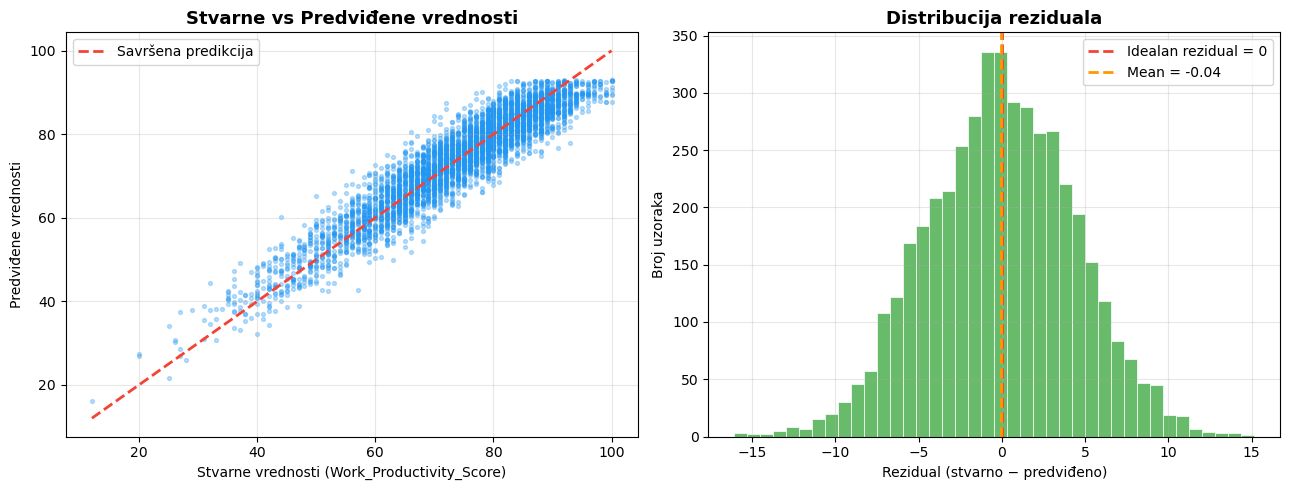

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=8, color='#2196F3')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#F44336', linewidth=2, linestyle='--', label='Savršena predikcija')
axes[0].set_title('Stvarne vs Predviđene vrednosti', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Stvarne vrednosti (Work_Productivity_Score)')
axes[0].set_ylabel('Predviđene vrednosti')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals = y_test - y_pred
axes[1].hist(residuals, bins=40, color='#4CAF50',
             edgecolor='white', linewidth=0.6, alpha=0.85)
axes[1].axvline(x=0, color='#F44336', linewidth=2,
                linestyle='--', label='Idealan rezidual = 0')
axes[1].axvline(x=residuals.mean(), color='#FF9800', linewidth=2,
                linestyle='--', label=f'Mean = {residuals.mean():.2f}')
axes[1].set_title('Distribucija reziduala', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rezidual (stvarno − predviđeno)')
axes[1].set_ylabel('Broj uzoraka')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Zapažanja:
- Scatter plot
    - Tačke su grupisane oko dijagonale - model dobro predviđa na svim nivoima produktivnosti
    - Malo odstupanje u donjem levom uglu prouzrokovano outlierima
- Distribucija reziduala
    - Simetrična oko nule
    - Model nije pristrasan ni pozitivnoj ni negativnoj strani

## Neuronska mreža sa dubljim slojevima
4 sloja i regularizacione tehnike(L2, Dropout i BatchNormalizatio)

In [27]:
def build_deep_model(input_dim, dropout_rate=0.2, l2_lambda=1e-4):
    inputs = keras.Input(shape=(input_dim,), name="input")

    x = layers.Dense(
        256, activation='relu',
        kernel_regularizer=regularizers.l2(l2_lambda),
        name="dense_1"
    )(inputs)
    x = layers.BatchNormalization(name="bn_1")(x)
    x = layers.Dropout(dropout_rate, name="dropout_1")(x)

    x = layers.Dense(
        128, activation='relu',
        kernel_regularizer=regularizers.l2(l2_lambda),
        name="dense_2"
    )(x)
    x = layers.BatchNormalization(name="bn_2")(x)
    x = layers.Dropout(dropout_rate, name="dropout_2")(x)

    x = layers.Dense(
        64, activation='relu',
        kernel_regularizer=regularizers.l2(l2_lambda),
        name="dense_3"
    )(x)
    x = layers.BatchNormalization(name="bn_3")(x)
    x = layers.Dropout(dropout_rate / 2, name="dropout_3")(x)

    x = layers.Dense(
        32, activation='relu',
        kernel_regularizer=regularizers.l2(l2_lambda),
        name="dense_4"
    )(x)
    x = layers.BatchNormalization(name="bn_4")(x)

    outputs = layers.Dense(1, name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="Deep_SleepNet")
    return model

deep_model = build_deep_model(input_dim=X_train_s.shape[1])

summary_data = []
for layer in deep_model.layers:
    summary_data.append({
        'Sloj': layer.name,
        'Tip': layer.__class__.__name__,
        'Izlazni oblik': str(layer.output.shape),
        'Parametri': layer.count_params()
    })

summary_df = pd.DataFrame(summary_data)
total = deep_model.count_params()
summary_df.loc[len(summary_df)] = ['UKUPNO', '', '', total]

print(f'Model: "{deep_model.name}"')
summary_df

Model: "Deep_SleepNet"


,Sloj,Tip,Izlazni oblik,Parametri
0,input,InputLayer,"(None, 7)",0
1,dense_1,Dense,"(None, 256)",2048
2,bn_1,BatchNormalization,"(None, 256)",1024
3,dropout_1,Dropout,"(None, 256)",0
4,dense_2,Dense,"(None, 128)",32896
5,bn_2,BatchNormalization,"(None, 128)",512
6,dropout_2,Dropout,"(None, 128)",0
7,dense_3,Dense,"(None, 64)",8256
8,bn_3,BatchNormalization,"(None, 64)",256
9,dropout_3,Dropout,"(None, 64)",0


In [28]:
deep_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',
    metrics=['mae']
)

In [29]:
callbacks_deep = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    )
]

In [30]:
history_deep = deep_model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=150,
    batch_size=256,
    callbacks=callbacks_deep,
    verbose=0
)


Epoch 34: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 41: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 42: early stopping
Restoring model weights from the end of the best epoch: 27.


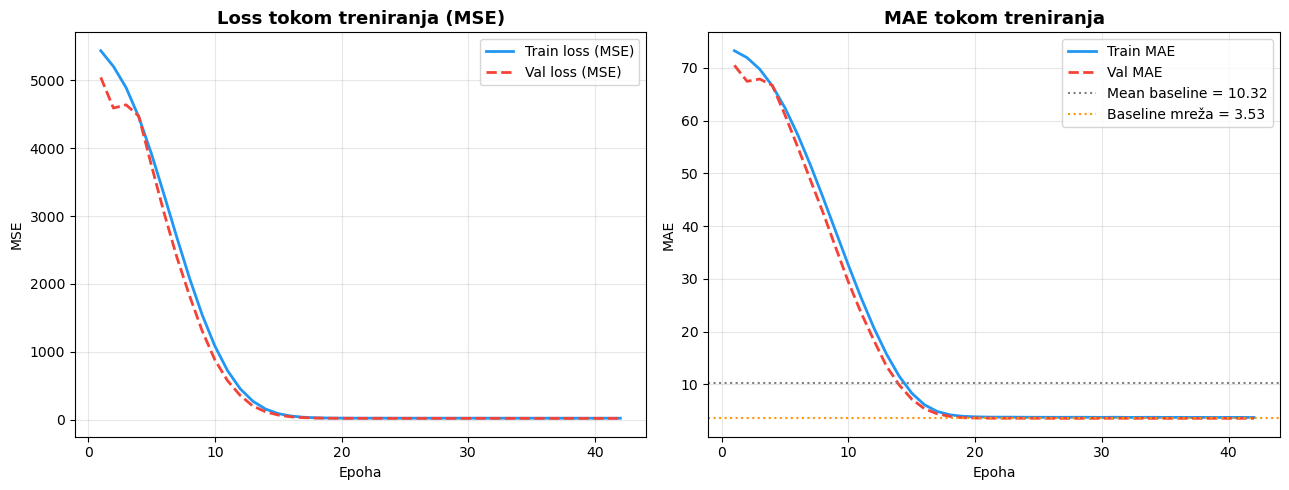

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, len(history_deep.history['loss']) + 1)

axes[0].plot(epochs_range, history_deep.history['loss'],
             label='Train loss (MSE)', color='#2196F3', linewidth=2)
axes[0].plot(epochs_range, history_deep.history['val_loss'],
             label='Val loss (MSE)', color='#F44336',
             linewidth=2, linestyle='--')
axes[0].set_title('Loss tokom treniranja (MSE)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_deep.history['mae'],
             label='Train MAE', color='#2196F3', linewidth=2)
axes[1].plot(epochs_range, history_deep.history['val_mae'],
             label='Val MAE', color='#F44336',
             linewidth=2, linestyle='--')
axes[1].axhline(y=mae_baseline, color='gray', linestyle=':',
                linewidth=1.5, label=f'Mean baseline = {mae_baseline:.2f}')
axes[1].axhline(y=history.history['val_mae'][-1], color='#FF9800',
                linestyle=':', linewidth=1.5,
                label=f'Baseline mreža = {history.history["val_mae"][-1]:.2f}')
axes[1].set_title('MAE tokom treniranja', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Zapažanje: 
- Manje strmoglav od Baseline-a
- Sporiji je po epohama, ali trenira kraće ukupno(manje epoha)

In [32]:
test_loss_f, test_mae_f = deep_model.evaluate(X_test_s, y_test, verbose=0)
y_pred_f = deep_model.predict(X_test_s, verbose=0).flatten()

test_rmse_f = np.sqrt(test_loss_f)
test_r2_f   = r2_score(y_test, y_pred_f)

eval_df = pd.DataFrame({
    'Metrika': ['MAE', 'RMSE', 'R²'],
    'Mean Predictor': [mae_baseline, rmse_baseline, r2_baseline],
    'Baseline SleepNet': [test_mae, test_rmse, test_r2],
    'Deep SleepNet': [test_mae_f, test_rmse_f, test_r2_f],
    'Poboljšanje (Deep vs Baseline)': [test_mae - test_mae_f, test_rmse - test_rmse_f, test_r2_f - test_r2]
})

print('Evaluacija — Deep SleepNet (Test set)')
eval_df

Evaluacija — Deep SleepNet (Test set)


,Metrika,Mean Predictor,Baseline SleepNet,Deep SleepNet,Poboljšanje (Deep vs Baseline)
0,MAE,10.324915,3.550245,3.568867,-0.018623
1,RMSE,12.955808,4.447645,4.479130,-0.031484
2,R²,-0.000081,0.882140,0.880681,-0.001459


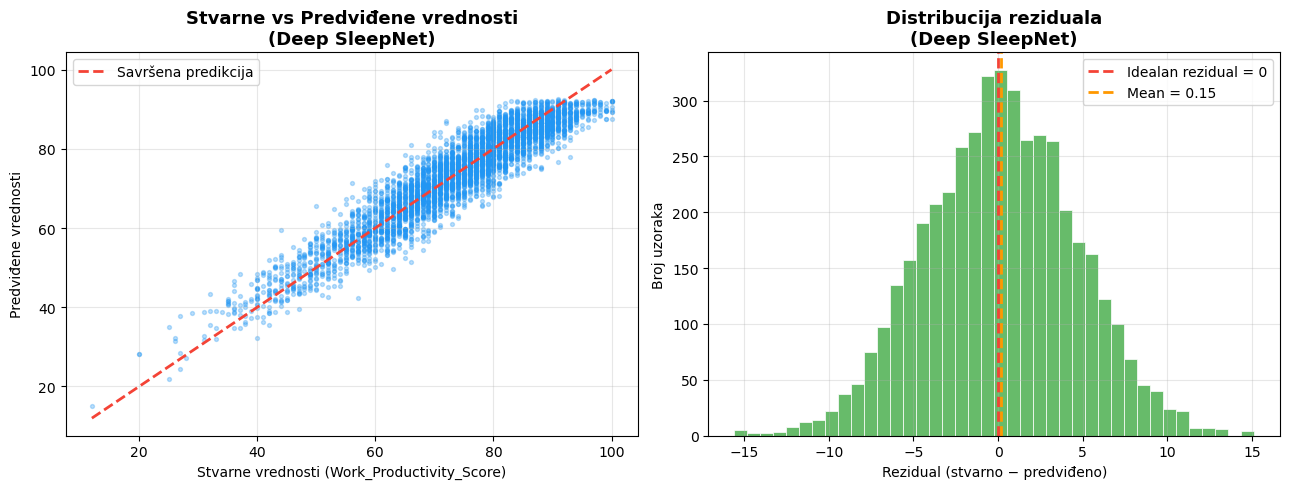

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_f, alpha=0.3, s=8, color='#2196F3')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#F44336', linewidth=2,
             linestyle='--', label='Savršena predikcija')
axes[0].set_title('Stvarne vs Predviđene vrednosti\n(Deep SleepNet)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Stvarne vrednosti (Work_Productivity_Score)')
axes[0].set_ylabel('Predviđene vrednosti')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals_f = y_test - y_pred_f
axes[1].hist(residuals_f, bins=40, color='#4CAF50',
             edgecolor='white', linewidth=0.6, alpha=0.85)
axes[1].axvline(x=0, color='#F44336', linewidth=2,
                linestyle='--', label='Idealan rezidual = 0')
axes[1].axvline(x=residuals_f.mean(), color='#FF9800', linewidth=2,
                linestyle='--', label=f'Mean = {residuals_f.mean():.2f}')
axes[1].set_title('Distribucija reziduala\n(Deep SleepNet)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rezidual (stvarno − predviđeno)')
axes[1].set_ylabel('Broj uzoraka')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Zapažanje: 
- Rezultati deep modela su gori od baseline rezultata.

## Feature engineering
Kombinovano sleep score, stres indikatori, kvardatni termini za nelinearne efekte

In [34]:
dataset['sleep_combined']    = dataset['Sleep_Hours'] * dataset['Sleep_Quality_Score']
dataset['sleep_efficiency']  = dataset['Sleep_Quality_Score'] / (dataset['Sleep_Hours'] + 1e-6)

dataset['stress_index']      = dataset['Caffeine_Intake_mg'] * dataset['Screen_Time_Before_Bed']
dataset['caffeine_per_hour'] = dataset['Caffeine_Intake_mg'] / (dataset['Sleep_Hours'] + 1e-6)

dataset['error_sq']          = dataset['Error_Rate'] ** 2
dataset['energy_mood']       = dataset['Energy_Level'] * dataset['Morning_Mood']


In [35]:
eng_features = ['sleep_combined', 'sleep_efficiency', 'stress_index',
                'caffeine_per_hour', 'error_sq', 'energy_mood']
try:
    _ = dataset
    need_load = not all(c in dataset.columns for c in eng_features)
except NameError:
    need_load = True
if need_load:
    dataset = pd.read_csv('Sleep_Patterns_vs_Daily_Performance.csv')
    mood_order = ['Very Bad', 'Bad', 'Neutral', 'Good', 'Excellent']
    mood_map = {m: i for i, m in enumerate(mood_order)}
    dataset['Morning_Mood'] = dataset['Morning_Mood'].map(mood_map)
    if 'sleep_bin' in dataset.columns:
        dataset = dataset.drop(columns=['sleep_bin'])
    dataset['sleep_combined']    = dataset['Sleep_Hours'] * dataset['Sleep_Quality_Score']
    dataset['sleep_efficiency']  = dataset['Sleep_Quality_Score'] / (dataset['Sleep_Hours'] + 1e-6)
    dataset['stress_index']      = dataset['Caffeine_Intake_mg'] * dataset['Screen_Time_Before_Bed']
    dataset['caffeine_per_hour'] = dataset['Caffeine_Intake_mg'] / (dataset['Sleep_Hours'] + 1e-6)
    dataset['error_sq']          = dataset['Error_Rate'] ** 2
    dataset['energy_mood']       = dataset['Energy_Level'] * dataset['Morning_Mood']

orig_features = ['Sleep_Hours', 'Sleep_Quality_Score', 'Caffeine_Intake_mg',
                 'Screen_Time_Before_Bed', 'Morning_Mood', 'Error_Rate', 'Energy_Level']

all_cols = orig_features + eng_features
corr_data = []
for col in all_cols:
    r = dataset[col].corr(dataset['Work_Productivity_Score'])
    corr_data.append({
        'Feature': col,
        'Tip': 'originalni' if col in orig_features else 'engineered',
        'Korelacija (r)': round(r, 4)
    })

corr_df = pd.DataFrame(corr_data).sort_values('Korelacija (r)', ascending=False, key=abs)
corr_df.index = range(1, len(corr_df) + 1)

print(f'Korelacija feature-a sa Work_Productivity_Score')
print(f'Originalni: {len(orig_features)} | Engineered: {len(eng_features)} | Ukupno: {len(all_cols)}')
corr_df

Korelacija feature-a sa Work_Productivity_Score
Originalni: 7 | Engineered: 6 | Ukupno: 13


,Feature,Tip,Korelacija (r)
1,Energy_Level,originalni,0.8841
2,Sleep_Quality_Score,originalni,0.8778
3,Error_Rate,originalni,-0.8510
4,error_sq,engineered,-0.8285
5,energy_mood,engineered,0.8028
6,sleep_combined,engineered,0.7807
7,Morning_Mood,originalni,0.7002
8,Sleep_Hours,originalni,0.5524
9,sleep_efficiency,engineered,0.3637
10,Screen_Time_Before_Bed,originalni,-0.3236


### Priprema podataka sa feature-engineered skupom

In [36]:

X_fe = dataset.drop(columns=['Work_Productivity_Score']).astype(float).values
y_fe = dataset['Work_Productivity_Score'].values.astype(float)

X_fe_train, X_fe_temp, y_fe_train, y_fe_temp = train_test_split(
    X_fe, y_fe, test_size=0.30, random_state=42
)
X_fe_val, X_fe_test, y_fe_val, y_fe_test = train_test_split(
    X_fe_temp, y_fe_temp, test_size=0.50, random_state=42
)

scaler_fe = StandardScaler()
X_fe_train_s = scaler_fe.fit_transform(X_fe_train)
X_fe_val_s   = scaler_fe.transform(X_fe_val)
X_fe_test_s  = scaler_fe.transform(X_fe_test)

print(f"Train:      {X_fe_train_s.shape[0]:,} uzoraka")
print(f"Validation: {X_fe_val_s.shape[0]:,} uzoraka")
print(f"Test:       {X_fe_test_s.shape[0]:,} uzoraka")
print(f"Broj feature-a: {X_fe_train_s.shape[1]}")


Train:      21,000 uzoraka
Validation: 4,500 uzoraka
Test:       4,500 uzoraka
Broj feature-a: 13


### Model: FeatureEng_SleepNet

In [37]:

def build_feature_eng_model(input_dim):
    inputs = keras.Input(shape=(input_dim,), name="input")

    x = layers.Dense(128, activation='relu', name="dense_1")(inputs)
    x = layers.Dense(64,  activation='relu', name="dense_2")(x)
    x = layers.Dense(32,  activation='relu', name="dense_3")(x)

    outputs = layers.Dense(1, name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs,
                        name="FeatureEng_SleepNet")
    return model

fe_model = build_feature_eng_model(input_dim=X_fe_train_s.shape[1])

summary_data = []
for layer in fe_model.layers:
    summary_data.append({
        'Sloj': layer.name,
        'Tip': layer.__class__.__name__,
        'Izlazni oblik': str(layer.output.shape),
        'Parametri': layer.count_params()
    })

summary_df = pd.DataFrame(summary_data)
total = fe_model.count_params()
summary_df.loc[len(summary_df)] = ['UKUPNO', '', '', total]

print(f'Model: "{fe_model.name}"')
summary_df


Model: "FeatureEng_SleepNet"


,Sloj,Tip,Izlazni oblik,Parametri
0,input,InputLayer,"(None, 13)",0
1,dense_1,Dense,"(None, 128)",1792
2,dense_2,Dense,"(None, 64)",8256
3,dense_3,Dense,"(None, 32)",2080
4,output,Dense,"(None, 1)",33
5,UKUPNO,,,12161


In [38]:

fe_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',
    metrics=['mae']
)

callbacks_fe = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]


In [39]:

history_fe = fe_model.fit(
    X_fe_train_s, y_fe_train,
    validation_data=(X_fe_val_s, y_fe_val),
    epochs=100,
    batch_size=256,
    callbacks=callbacks_fe,
    verbose=0
)



Epoch 38: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 45: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 51: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 56: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 56: early stopping
Restoring model weights from the end of the best epoch: 46.


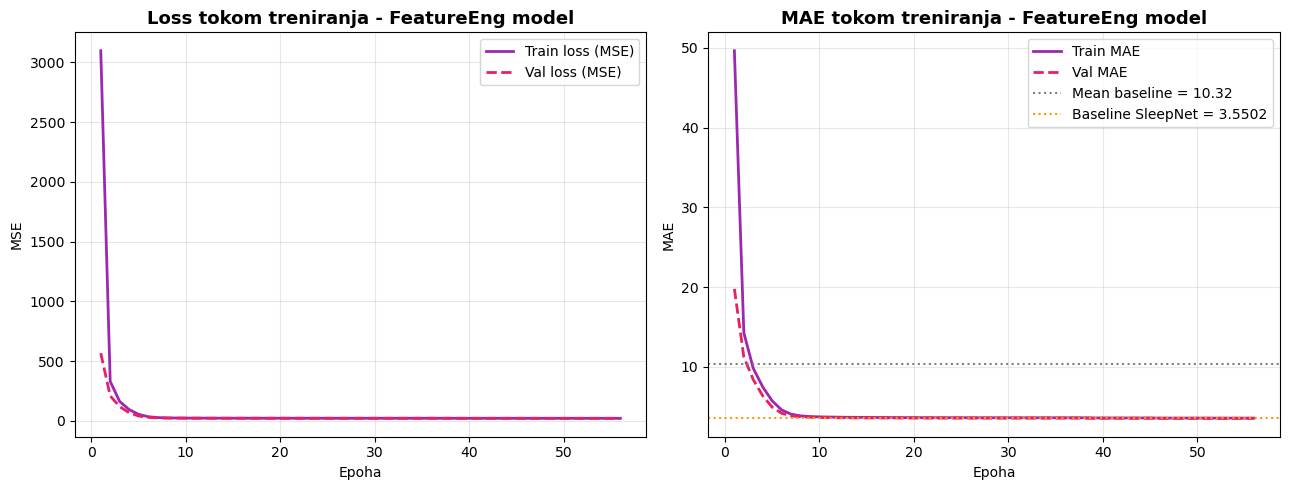

In [40]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, len(history_fe.history['loss']) + 1)

axes[0].plot(epochs_range, history_fe.history['loss'],
             label='Train loss (MSE)', color='#9C27B0', linewidth=2)
axes[0].plot(epochs_range, history_fe.history['val_loss'],
             label='Val loss (MSE)', color='#E91E63', linewidth=2, linestyle='--')
axes[0].set_title('Loss tokom treniranja - FeatureEng model', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_fe.history['mae'],
             label='Train MAE', color='#9C27B0', linewidth=2)
axes[1].plot(epochs_range, history_fe.history['val_mae'],
             label='Val MAE', color='#E91E63', linewidth=2, linestyle='--')
axes[1].axhline(y=mae_baseline, color='gray', linestyle=':',
                linewidth=1.5, label=f'Mean baseline = {mae_baseline:.2f}')
axes[1].axhline(y=test_mae, color='#FF9800', linestyle=':',
                linewidth=1.5, label=f'Baseline SleepNet = {test_mae:.4f}')
axes[1].set_title('MAE tokom treniranja - FeatureEng model', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


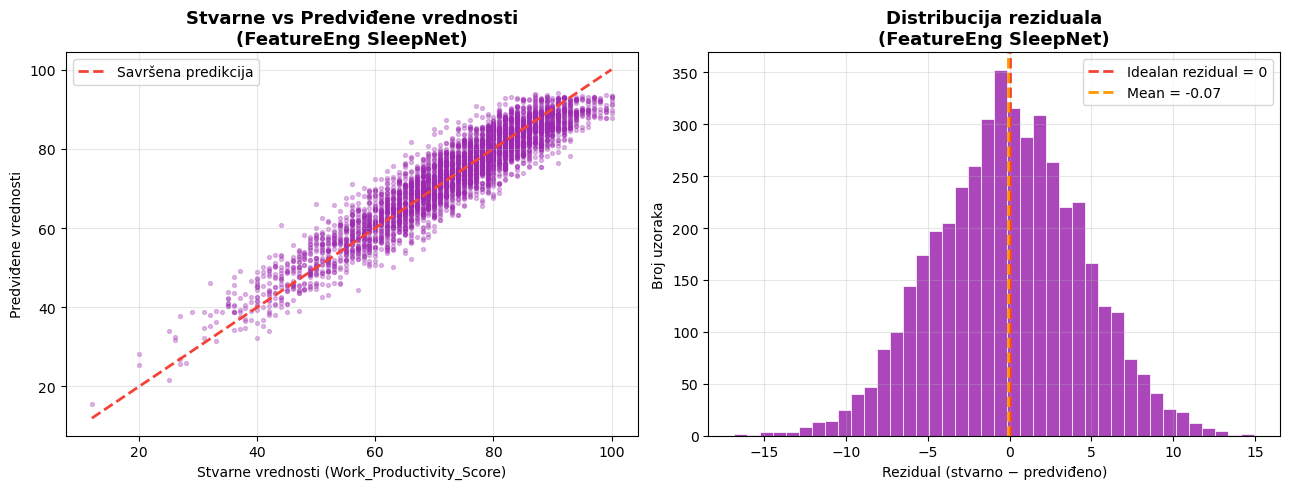

In [41]:

test_loss_fe, test_mae_fe = fe_model.evaluate(X_fe_test_s, y_fe_test, verbose=0)
y_pred_fe = fe_model.predict(X_fe_test_s, verbose=0).flatten()

test_rmse_fe = np.sqrt(test_loss_fe)
test_r2_fe   = r2_score(y_fe_test, y_pred_fe)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_fe_test, y_pred_fe, alpha=0.3, s=8, color='#9C27B0')
axes[0].plot([y_fe_test.min(), y_fe_test.max()],
             [y_fe_test.min(), y_fe_test.max()],
             color='#F44336', linewidth=2, linestyle='--', label='Savršena predikcija')
axes[0].set_title(f'Stvarne vs Predviđene vrednosti\n(FeatureEng SleepNet)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Stvarne vrednosti (Work_Productivity_Score)')
axes[0].set_ylabel('Predviđene vrednosti')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals_fe = y_fe_test - y_pred_fe
axes[1].hist(residuals_fe, bins=40, color='#9C27B0',
             edgecolor='white', linewidth=0.6, alpha=0.85)
axes[1].axvline(x=0, color='#F44336', linewidth=2,
                linestyle='--', label='Idealan rezidual = 0')
axes[1].axvline(x=residuals_fe.mean(), color='#FF9800', linewidth=2,
                linestyle='--', label=f'Mean = {residuals_fe.mean():.2f}')
axes[1].set_title('Distribucija reziduala\n(FeatureEng SleepNet)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rezidual (stvarno − predviđeno)')
axes[1].set_ylabel('Broj uzoraka')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [42]:

print("=" * 70)
print("POREĐENJE SVIH MODELA — Test set")
print("=" * 70)
print(f"{'Model':<30} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'Epohe':>7} {'Feature-i':>10}")
print("-" * 70)
print(f"{'Mean Predictor':<30} {mae_baseline:>8.4f} {rmse_baseline:>8.4f} {r2_baseline:>8.4f} {'—':>7} {'7':>10}")
print(f"{'Baseline SleepNet':<30} {test_mae:>8.4f} {test_rmse:>8.4f} {test_r2:>8.4f} {'80':>7} {'7':>10}")
print(f"{'Deep SleepNet v1':<30} {test_mae_f:>8.4f} {test_rmse_f:>8.4f} {test_r2_f:>8.4f} {'44':>7} {'7':>10}")
print(f"{'FeatureEng SleepNet':<30} {test_mae_fe:>8.4f} {test_rmse_fe:>8.4f} {test_r2_fe:>8.4f} {len(history_fe.history['loss']):>7} {'13':>10}")
print("=" * 70)
print(f"\nPoboljšanje FeatureEng vs Baseline SleepNet:")
print(f"  MAE:  {test_mae - test_mae_fe:+.4f}  ({(test_mae - test_mae_fe)/test_mae*100:+.2f}%)")
print(f"  RMSE: {test_rmse - test_rmse_fe:+.4f}  ({(test_rmse - test_rmse_fe)/test_rmse*100:+.2f}%)")
print(f"  R²:   {test_r2_fe - test_r2:+.4f}")


POREĐENJE SVIH MODELA — Test set
Model                               MAE     RMSE       R²   Epohe  Feature-i
----------------------------------------------------------------------
Mean Predictor                  10.3249  12.9558  -0.0001       —          7
Baseline SleepNet                3.5502   4.4476   0.8821      80          7
Deep SleepNet v1                 3.5689   4.4791   0.8807      44          7
FeatureEng SleepNet              3.5783   4.4851   0.8801      56         13

Poboljšanje FeatureEng vs Baseline SleepNet:
  MAE:  -0.0280  (-0.79%)
  RMSE: -0.0374  (-0.84%)
  R²:   -0.0020


### Residualna mreža — ResNet_SleepNet

Umesto da povećavamo dubinu ili širinu, uvodimo **skip connections** (residualne veze) koje preskaču slojeve.

**Zašto residualne veze?**
- Gradient može da "prođe" direktno unazad kroz skip vezu, bez degradacije
- Model uči **rezidual** (korekciju) umesto pune transformacije
- Čak i ako novi slojevi ne pomažu, mreža može da "ignoriše" blok postavivši težine na ≈0 i koristiti skip
- Arhitektura: `Input → Projekcija(64) → [ResBlok1] → [ResBlok2] → Dense(32) → Output`
- Svaki ResBlok: `Dense→BN→ReLU→Dense→BN→Add(skip)→ReLU`
- Isti 7 originalnih feature-a kao baseline — testiramo čistu razliku u arhitekturi

In [43]:

def build_residual_model(input_dim):
    inputs = keras.Input(shape=(input_dim,), name="input")

    # Ulazna projekcija na 64 dimenzije
    x = layers.Dense(64, name="projection")(inputs)

    # --- Residualni blok 1 ---
    skip1 = x
    x = layers.Dense(64, name="res1_dense1")(x)
    x = layers.BatchNormalization(name="res1_bn1")(x)
    x = layers.Activation('relu', name="res1_relu1")(x)
    x = layers.Dense(64, name="res1_dense2")(x)
    x = layers.BatchNormalization(name="res1_bn2")(x)
    x = layers.Add(name="res1_add")([x, skip1])
    x = layers.Activation('relu', name="res1_out")(x)

    # --- Residualni blok 2 ---
    skip2 = x
    x = layers.Dense(64, name="res2_dense1")(x)
    x = layers.BatchNormalization(name="res2_bn1")(x)
    x = layers.Activation('relu', name="res2_relu1")(x)
    x = layers.Dense(64, name="res2_dense2")(x)
    x = layers.BatchNormalization(name="res2_bn2")(x)
    x = layers.Add(name="res2_add")([x, skip2])
    x = layers.Activation('relu', name="res2_out")(x)

    # Izlazna glava
    x = layers.Dense(32, activation='relu', name="head")(x)
    outputs = layers.Dense(1, name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="ResNet_SleepNet")
    return model

resnet_model = build_residual_model(input_dim=X_train_s.shape[1])

summary_data = []
for layer in resnet_model.layers:
    summary_data.append({
        'Sloj': layer.name,
        'Tip': layer.__class__.__name__,
        'Izlazni oblik': str(layer.output.shape),
        'Parametri': layer.count_params()
    })

summary_df = pd.DataFrame(summary_data)
total = resnet_model.count_params()
summary_df.loc[len(summary_df)] = ['UKUPNO', '', '', total]

print(f'Model: "{resnet_model.name}"')
summary_df


Model: "ResNet_SleepNet"


,Sloj,Tip,Izlazni oblik,Parametri
0,input,InputLayer,"(None, 7)",0
1,projection,Dense,"(None, 64)",512
2,res1_dense1,Dense,"(None, 64)",4160
3,res1_bn1,BatchNormalization,"(None, 64)",256
4,res1_relu1,Activation,"(None, 64)",0
5,res1_dense2,Dense,"(None, 64)",4160
6,res1_bn2,BatchNormalization,"(None, 64)",256
7,res1_add,Add,"(None, 64)",0
8,res1_out,Activation,"(None, 64)",0
9,res2_dense1,Dense,"(None, 64)",4160


In [44]:

resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',
    metrics=['mae']
)

callbacks_resnet = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]


In [45]:

history_resnet = resnet_model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,
    batch_size=256,
    callbacks=callbacks_resnet,
    verbose=1
)

print(f"\nTreniranje završeno.")
print(f"Broj otrenirani epoha: {len(history_resnet.history['loss'])}")
print(f"Deep train MAE:      {history_resnet.history['mae'][-1]:.4f}")
print(f"Deep validation MAE: {history_resnet.history['val_mae'][-1]:.4f}")


Epoch 1/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4116.4971 - mae: 62.7172 - val_loss: 2688.5728 - val_mae: 50.7773 - learning_rate: 0.0010
Epoch 2/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 485.3040 - mae: 17.0449 - val_loss: 566.3065 - val_mae: 22.4475 - learning_rate: 0.0010
Epoch 3/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 27.5891 - mae: 4.1687 - val_loss: 213.7326 - val_mae: 13.8241 - learning_rate: 0.0010
Epoch 4/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 25.9556 - mae: 4.0567 - val_loss: 84.1640 - val_mae: 8.0979 - learning_rate: 0.0010
Epoch 5/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 25.2512 - mae: 4.0043 - val_loss: 48.5816 - val_mae: 5.8253 - learning_rate: 0.0010
Epoch 6/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 24.7081 - mae: 3.9641 - val_loss: 36.0259 - val_mae: 4.8895 - learning_rate: 0.0010
Epoch 7/100
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 24.2485 - mae: 3.9301 - val_loss: 31.0561 - val_mae: 4.4954 - learning_

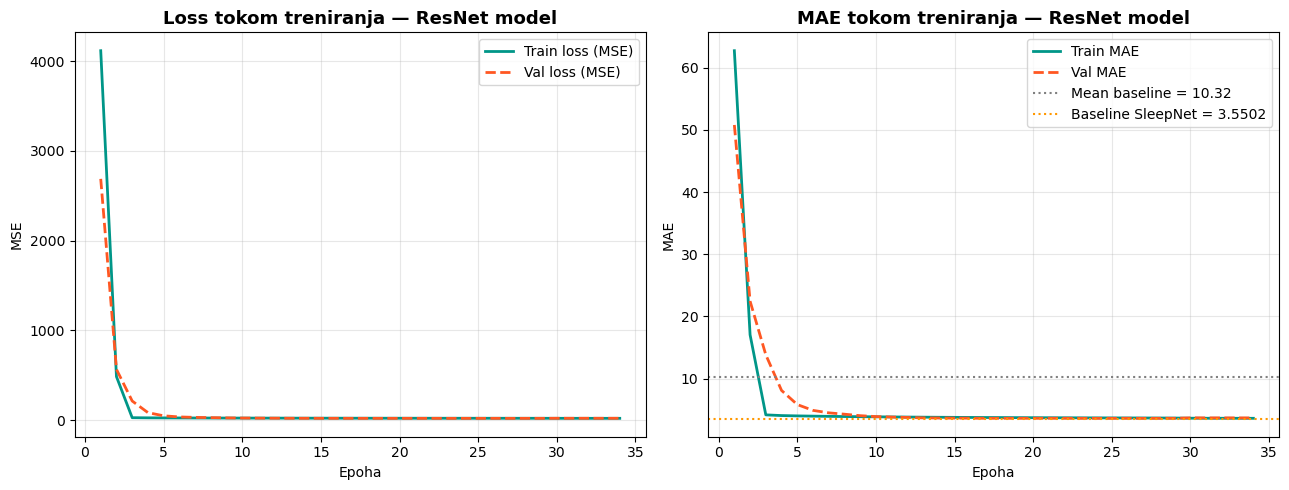

In [46]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, len(history_resnet.history['loss']) + 1)

axes[0].plot(epochs_range, history_resnet.history['loss'],
             label='Train loss (MSE)', color='#009688', linewidth=2)
axes[0].plot(epochs_range, history_resnet.history['val_loss'],
             label='Val loss (MSE)', color='#FF5722', linewidth=2, linestyle='--')
axes[0].set_title('Loss tokom treniranja — ResNet model', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_resnet.history['mae'],
             label='Train MAE', color='#009688', linewidth=2)
axes[1].plot(epochs_range, history_resnet.history['val_mae'],
             label='Val MAE', color='#FF5722', linewidth=2, linestyle='--')
axes[1].axhline(y=mae_baseline, color='gray', linestyle=':',
                linewidth=1.5, label=f'Mean baseline = {mae_baseline:.2f}')
axes[1].axhline(y=test_mae, color='#FF9800', linestyle=':',
                linewidth=1.5, label=f'Baseline SleepNet = {test_mae:.4f}')
axes[1].set_title('MAE tokom treniranja — ResNet model', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


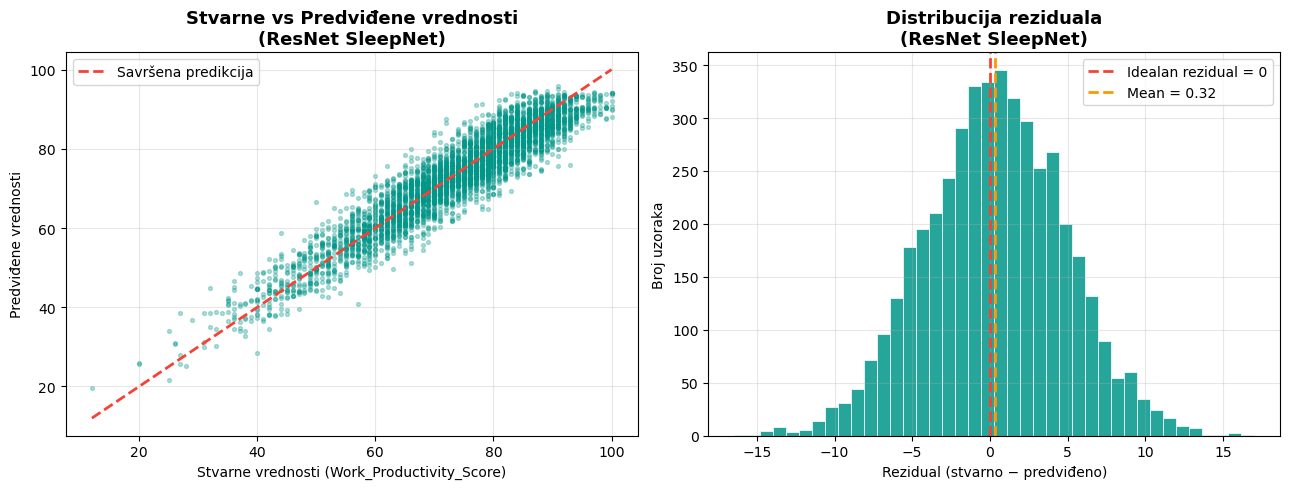

In [47]:

test_loss_res, test_mae_res = resnet_model.evaluate(X_test_s, y_test, verbose=0)
y_pred_res = resnet_model.predict(X_test_s, verbose=0).flatten()

test_rmse_res = np.sqrt(test_loss_res)
test_r2_res   = r2_score(y_test, y_pred_res)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_res, alpha=0.3, s=8, color='#009688')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#F44336', linewidth=2, linestyle='--', label='Savršena predikcija')
axes[0].set_title('Stvarne vs Predviđene vrednosti\n(ResNet SleepNet)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Stvarne vrednosti (Work_Productivity_Score)')
axes[0].set_ylabel('Predviđene vrednosti')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals_res = y_test - y_pred_res
axes[1].hist(residuals_res, bins=40, color='#009688',
             edgecolor='white', linewidth=0.6, alpha=0.85)
axes[1].axvline(x=0, color='#F44336', linewidth=2,
                linestyle='--', label='Idealan rezidual = 0')
axes[1].axvline(x=residuals_res.mean(), color='#FF9800', linewidth=2,
                linestyle='--', label=f'Mean = {residuals_res.mean():.2f}')
axes[1].set_title('Distribucija reziduala\n(ResNet SleepNet)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rezidual (stvarno − predviđeno)')
axes[1].set_ylabel('Broj uzoraka')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [48]:

print("=" * 70)
print("POREĐENJE SVIH MODELA — Test set")
print("=" * 70)
print(f"{'Model':<26} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'Epohe':>7}")
print("-" * 70)
print(f"{'Mean Predictor':<26} {mae_baseline:>8.4f} {rmse_baseline:>8.4f} {r2_baseline:>8.4f} {'—':>7}")
print(f"{'Baseline SleepNet':<26} {test_mae:>8.4f} {test_rmse:>8.4f} {test_r2:>8.4f} {len(history.history['loss']):>7}")
print(f"{'Deep SleepNet v1':<26} {test_mae_f:>8.4f} {test_rmse_f:>8.4f} {test_r2_f:>8.4f} {len(history_deep.history['loss']):>7}")
print(f"{'ResNet SleepNet':<26} {test_mae_res:>8.4f} {test_rmse_res:>8.4f} {test_r2_res:>8.4f} {len(history_resnet.history['loss']):>7}")
print("=" * 70)
print(f"\nPoboljšanje ResNet vs Baseline SleepNet:")
print(f"  MAE:  {test_mae - test_mae_res:+.4f}  ({(test_mae - test_mae_res) / test_mae * 100:+.2f}%)")
print(f"  RMSE: {test_rmse - test_rmse_res:+.4f}  ({(test_rmse - test_rmse_res) / test_rmse * 100:+.2f}%)")
print(f"  R²:   {test_r2_res - test_r2:+.4f}")


POREĐENJE SVIH MODELA — Test set
Model                           MAE     RMSE       R²   Epohe
----------------------------------------------------------------------
Mean Predictor              10.3249  12.9558  -0.0001       —
Baseline SleepNet            3.5502   4.4476   0.8821     100
Deep SleepNet v1             3.5689   4.4791   0.8807      42
ResNet SleepNet              3.6131   4.5397   0.8772      34

Poboljšanje ResNet vs Baseline SleepNet:
  MAE:  -0.0629  (-1.77%)
  RMSE: -0.0920  (-2.07%)
  R²:   -0.0049


### Huber loss — Huber_SleepNet

Do sada svi modeli koriste **MSE (Mean Squared Error)** kao loss funkciju.  
Problem MSE-a: kvadratno kažnjava greške, pa su **outlieri** (npr. ekstremne vrednosti `Caffeine_Intake_mg`, `Screen_Time_Before_Bed`) disproporcionalno uticajni na gradijent.

**Huber loss** kombinuje MSE i MAE:
- Za male greške (|e| ≤ δ): ponaša se kao MSE → osetljiv na fine razlike
- Za velike greške (|e| > δ): ponaša se kao MAE → robustno na outliere, gradijent ne eksplodira

```
L(e) = 0.5 * e²              ako |e| ≤ δ
L(e) = δ * (|e| - 0.5 * δ)  ako |e| > δ
```

Koristimo δ=1.0 (standardna vrednost). Arhitektura je identična Baseline SleepNet (64→32, bez regularizacije) — testiramo **samo efekat loss funkcije**.

In [49]:

def build_huber_model(input_dim):
    inputs = keras.Input(shape=(input_dim,), name="input")

    x = layers.Dense(64, activation='relu', name="dense_1")(inputs)
    x = layers.Dense(32, activation='relu', name="dense_2")(x)

    outputs = layers.Dense(1, name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="Huber_SleepNet")
    return model

huber_model = build_huber_model(input_dim=X_train_s.shape[1])

summary_data = []
for layer in huber_model.layers:
    summary_data.append({
        'Sloj': layer.name,
        'Tip': layer.__class__.__name__,
        'Izlazni oblik': str(layer.output.shape),
        'Parametri': layer.count_params()
    })

summary_df = pd.DataFrame(summary_data)
total = huber_model.count_params()
summary_df.loc[len(summary_df)] = ['UKUPNO', '', '', total]

print(f'Model: "{huber_model.name}"')
summary_df


Model: "Huber_SleepNet"


,Sloj,Tip,Izlazni oblik,Parametri
0,input,InputLayer,"(None, 7)",0
1,dense_1,Dense,"(None, 64)",512
2,dense_2,Dense,"(None, 32)",2080
3,output,Dense,"(None, 1)",33
4,UKUPNO,,,2625


In [50]:

huber_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.Huber(delta=1.0),
    metrics=['mae']
)

callbacks_huber = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]


In [51]:

history_huber = huber_model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,
    batch_size=256,
    callbacks=callbacks_huber,
    verbose=0
)



Epoch 47: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 52: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 52: early stopping
Restoring model weights from the end of the best epoch: 42.


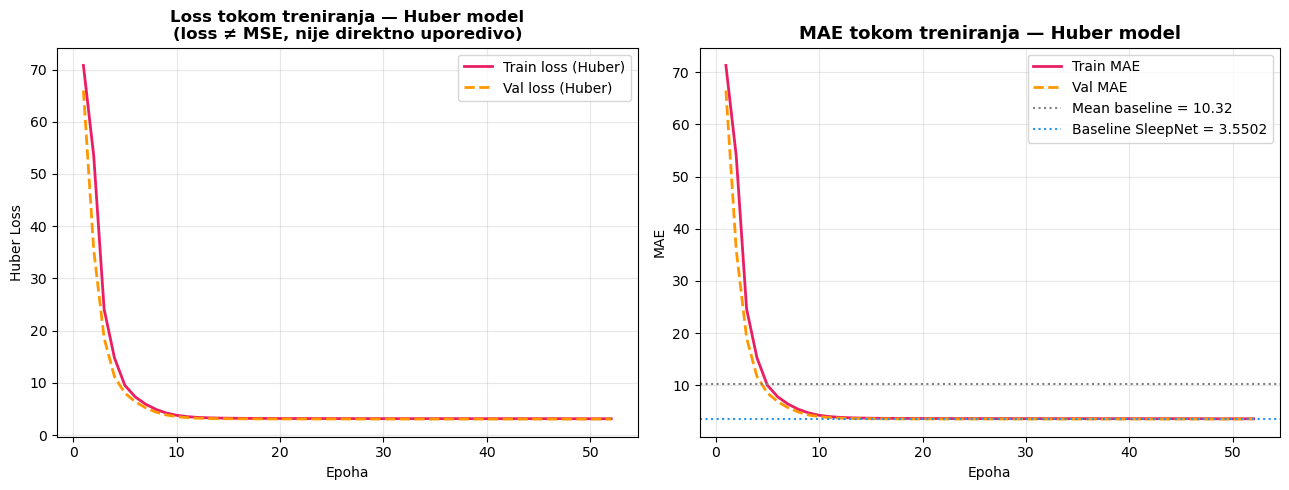

In [52]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, len(history_huber.history['loss']) + 1)

axes[0].plot(epochs_range, history_huber.history['loss'],
             label='Train loss (Huber)', color='#E91E63', linewidth=2)
axes[0].plot(epochs_range, history_huber.history['val_loss'],
             label='Val loss (Huber)', color='#FF9800', linewidth=2, linestyle='--')
axes[0].set_title('Loss tokom treniranja — Huber model\n(loss ≠ MSE, nije direktno uporedivo)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('Huber Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_huber.history['mae'],
             label='Train MAE', color='#E91E63', linewidth=2)
axes[1].plot(epochs_range, history_huber.history['val_mae'],
             label='Val MAE', color='#FF9800', linewidth=2, linestyle='--')
axes[1].axhline(y=mae_baseline, color='gray', linestyle=':',
                linewidth=1.5, label=f'Mean baseline = {mae_baseline:.2f}')
axes[1].axhline(y=test_mae, color='#2196F3', linestyle=':',
                linewidth=1.5, label=f'Baseline SleepNet = {test_mae:.4f}')
axes[1].set_title('MAE tokom treniranja — Huber model', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


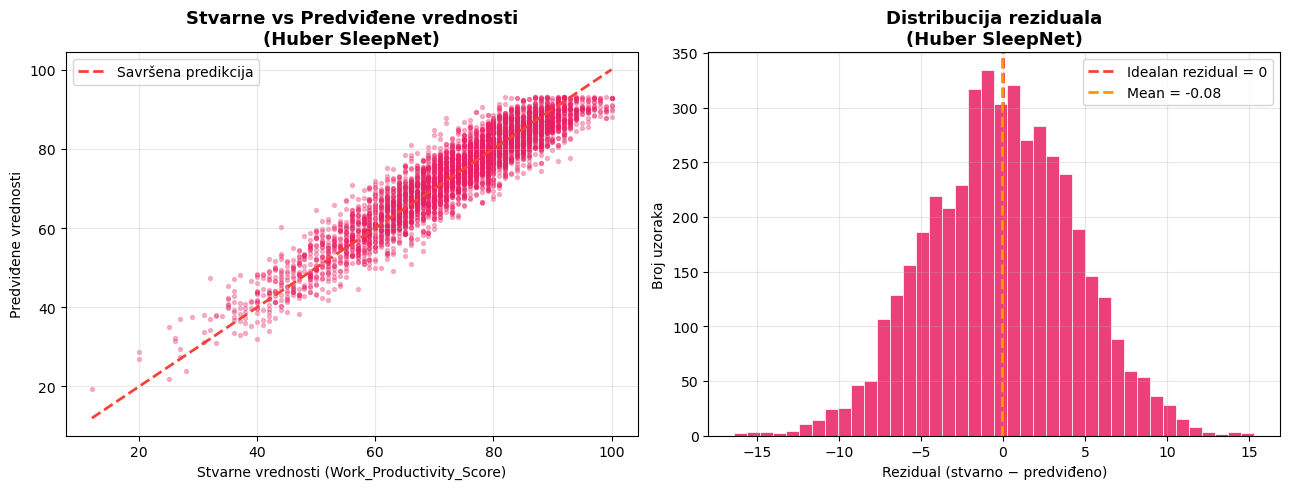

In [53]:

# Evaluacija — MSE/RMSE se računaju ručno jer je loss=Huber, ne MSE
y_pred_huber = huber_model.predict(X_test_s, verbose=0).flatten()

test_mae_huber  = mean_absolute_error(y_test, y_pred_huber)
test_rmse_huber = np.sqrt(mean_squared_error(y_test, y_pred_huber))
test_r2_huber   = r2_score(y_test, y_pred_huber)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_huber, alpha=0.3, s=8, color='#E91E63')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#F44336', linewidth=2, linestyle='--', label='Savršena predikcija')
axes[0].set_title('Stvarne vs Predviđene vrednosti\n(Huber SleepNet)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Stvarne vrednosti (Work_Productivity_Score)')
axes[0].set_ylabel('Predviđene vrednosti')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals_huber = y_test - y_pred_huber
axes[1].hist(residuals_huber, bins=40, color='#E91E63',
             edgecolor='white', linewidth=0.6, alpha=0.85)
axes[1].axvline(x=0, color='#F44336', linewidth=2,
                linestyle='--', label='Idealan rezidual = 0')
axes[1].axvline(x=residuals_huber.mean(), color='#FF9800', linewidth=2,
                linestyle='--', label=f'Mean = {residuals_huber.mean():.2f}')
axes[1].set_title('Distribucija reziduala\n(Huber SleepNet)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rezidual (stvarno − predviđeno)')
axes[1].set_ylabel('Broj uzoraka')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [54]:

print("=" * 70)
print("POREĐENJE SVIH MODELA — Test set")
print("=" * 70)
print(f"{'Model':<26} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'Epohe':>7} {'Loss':>8}")
print("-" * 70)
print(f"{'Mean Predictor':<26} {mae_baseline:>8.4f} {rmse_baseline:>8.4f} {r2_baseline:>8.4f} {'—':>7} {'—':>8}")
print(f"{'Baseline SleepNet':<26} {test_mae:>8.4f} {test_rmse:>8.4f} {test_r2:>8.4f} {len(history.history['loss']):>7} {'MSE':>8}")
print(f"{'Deep SleepNet v1':<26} {test_mae_f:>8.4f} {test_rmse_f:>8.4f} {test_r2_f:>8.4f} {len(history_deep.history['loss']):>7} {'MSE':>8}")
print(f"{'ResNet SleepNet':<26} {test_mae_res:>8.4f} {test_rmse_res:>8.4f} {test_r2_res:>8.4f} {len(history_resnet.history['loss']):>7} {'MSE':>8}")
print(f"{'Huber SleepNet':<26} {test_mae_huber:>8.4f} {test_rmse_huber:>8.4f} {test_r2_huber:>8.4f} {len(history_huber.history['loss']):>7} {'Huber':>8}")
print("=" * 70)
print(f"\nPoboljšanje Huber vs Baseline SleepNet:")
print(f"  MAE:  {test_mae - test_mae_huber:+.4f}  ({(test_mae - test_mae_huber) / test_mae * 100:+.2f}%)")
print(f"  RMSE: {test_rmse - test_rmse_huber:+.4f}  ({(test_rmse - test_rmse_huber) / test_rmse * 100:+.2f}%)")
print(f"  R²:   {test_r2_huber - test_r2:+.4f}")


POREĐENJE SVIH MODELA — Test set
Model                           MAE     RMSE       R²   Epohe     Loss
----------------------------------------------------------------------
Mean Predictor              10.3249  12.9558  -0.0001       —        —
Baseline SleepNet            3.5502   4.4476   0.8821     100      MSE
Deep SleepNet v1             3.5689   4.4791   0.8807      42      MSE
ResNet SleepNet              3.6131   4.5397   0.8772      34      MSE
Huber SleepNet               3.5854   4.4829   0.8803      52    Huber

Poboljšanje Huber vs Baseline SleepNet:
  MAE:  -0.0352  (-0.99%)
  RMSE: -0.0353  (-0.79%)
  R²:   -0.0019


### Manji batch size + AdamW — AdamW_SleepNet

Dva odvojena poboljšanja u jednom eksperimentu:

**AdamW (Adam + Weight Decay):**
- Standardni Adam ugrađuje L2 regularizaciju u gradijent (što je matematički neispravno)
- AdamW ispravlja ovo odvajanjem weight decay-a od adaptivnog koraka
- Rezultat: bolja generalizacija bez eksplicitnog dodavanja L2 regularizatora

**Manji batch size (64 umesto 256):**
- Veliki batch → glatki, ali "ravni" gradijenti → model se lakše zaglavi u plitkim minimumima
- Mali batch → šumovitiiji gradijenti, ali → bolje istraživanje prostora parametara → bolji minimum
- Tradeoff: sporije po epohi, ali tipično manje epoha do konvergencije

Arhitektura ostaje ista kao Baseline SleepNet (64→32) — testiramo samo optimizator i batch size.

In [55]:

def build_adamw_model(input_dim):
    inputs = keras.Input(shape=(input_dim,), name="input")

    x = layers.Dense(64, activation='relu', name="dense_1")(inputs)
    x = layers.Dense(32, activation='relu', name="dense_2")(x)

    outputs = layers.Dense(1, name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="AdamW_SleepNet")
    return model

adamw_model = build_adamw_model(input_dim=X_train_s.shape[1])

summary_data = []
for layer in adamw_model.layers:
    summary_data.append({
        'Sloj': layer.name,
        'Tip': layer.__class__.__name__,
        'Izlazni oblik': str(layer.output.shape),
        'Parametri': layer.count_params()
    })

summary_df = pd.DataFrame(summary_data)
total = adamw_model.count_params()
summary_df.loc[len(summary_df)] = ['UKUPNO', '', '', total]

print(f'Model: "{adamw_model.name}"')
summary_df


Model: "AdamW_SleepNet"


,Sloj,Tip,Izlazni oblik,Parametri
0,input,InputLayer,"(None, 7)",0
1,dense_1,Dense,"(None, 64)",512
2,dense_2,Dense,"(None, 32)",2080
3,output,Dense,"(None, 1)",33
4,UKUPNO,,,2625


In [56]:

adamw_model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=5e-4, weight_decay=1e-5),
    loss='mean_squared_error',
    metrics=['mae']
)

callbacks_adamw = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]


In [57]:

history_adamw = adamw_model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,
    batch_size=64,
    callbacks=callbacks_adamw,
    verbose=1
)

print(f"\nTreniranje završeno.")
print(f"Broj otrenirani epoha: {len(history_adamw.history['loss'])}")
print(f"Deep train MAE:      {history_adamw.history['mae'][-1]:.4f}")
print(f"Deep validation MAE: {history_adamw.history['val_mae'][-1]:.4f}")


Epoch 1/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 643us/step - loss: 3537.5515 - mae: 55.4460 - val_loss: 860.5593 - val_mae: 25.0574 - learning_rate: 5.0000e-04
Epoch 2/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 410us/step - loss: 512.2015 - mae: 18.4952 - val_loss: 265.9337 - val_mae: 13.1016 - learning_rate: 5.0000e-04
Epoch 3/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 407us/step - loss: 179.2099 - mae: 10.4953 - val_loss: 123.2927 - val_mae: 8.6498 - learning_rate: 5.0000e-04
Epoch 4/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 406us/step - loss: 97.9735 - mae: 7.7149 - val_loss: 76.3305 - val_mae: 6.8005 - learning_rate: 5.0000e-04
Epoch 5/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 405us/step - loss: 63.6923 - mae: 6.2353 - val_loss: 51.0425 - val_mae: 5.5811 - learning_rate: 5.0000e-04
Epoch 6/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 403us/step - loss: 44.6673 - mae: 5.2542 - val_loss: 36.9946 - val_mae: 4.7763 - learning_rate: 5.0000e-04
Epoch 7/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 404us/step - loss: 34.0423 - mae: 4.61

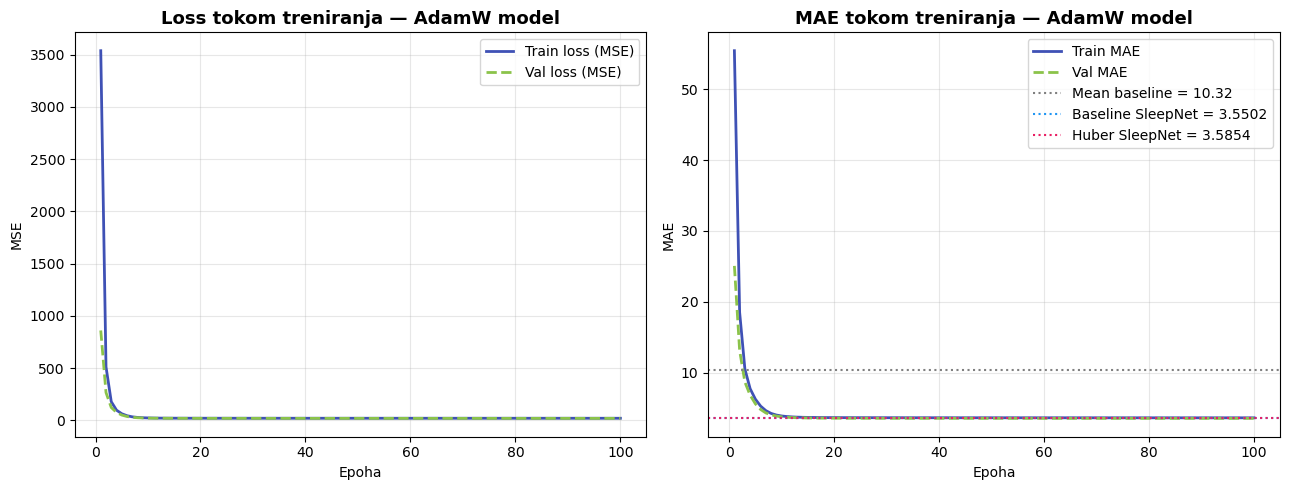

In [58]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, len(history_adamw.history['loss']) + 1)

axes[0].plot(epochs_range, history_adamw.history['loss'],
             label='Train loss (MSE)', color='#3F51B5', linewidth=2)
axes[0].plot(epochs_range, history_adamw.history['val_loss'],
             label='Val loss (MSE)', color='#8BC34A', linewidth=2, linestyle='--')
axes[0].set_title('Loss tokom treniranja — AdamW model', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_adamw.history['mae'],
             label='Train MAE', color='#3F51B5', linewidth=2)
axes[1].plot(epochs_range, history_adamw.history['val_mae'],
             label='Val MAE', color='#8BC34A', linewidth=2, linestyle='--')
axes[1].axhline(y=mae_baseline, color='gray', linestyle=':',
                linewidth=1.5, label=f'Mean baseline = {mae_baseline:.2f}')
axes[1].axhline(y=test_mae, color='#2196F3', linestyle=':',
                linewidth=1.5, label=f'Baseline SleepNet = {test_mae:.4f}')
axes[1].axhline(y=test_mae_huber, color='#E91E63', linestyle=':',
                linewidth=1.5, label=f'Huber SleepNet = {test_mae_huber:.4f}')
axes[1].set_title('MAE tokom treniranja — AdamW model', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


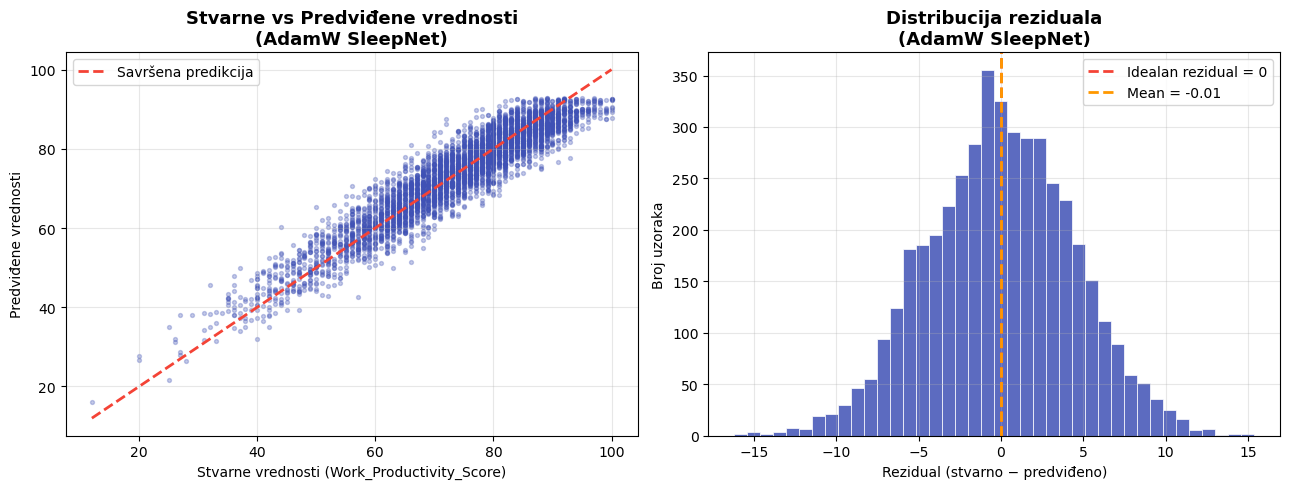

In [59]:

test_loss_adamw, test_mae_adamw = adamw_model.evaluate(X_test_s, y_test, verbose=0)
y_pred_adamw = adamw_model.predict(X_test_s, verbose=0).flatten()

test_rmse_adamw = np.sqrt(test_loss_adamw)
test_r2_adamw   = r2_score(y_test, y_pred_adamw)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_adamw, alpha=0.3, s=8, color='#3F51B5')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#F44336', linewidth=2, linestyle='--', label='Savršena predikcija')
axes[0].set_title('Stvarne vs Predviđene vrednosti\n(AdamW SleepNet)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Stvarne vrednosti (Work_Productivity_Score)')
axes[0].set_ylabel('Predviđene vrednosti')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals_adamw = y_test - y_pred_adamw
axes[1].hist(residuals_adamw, bins=40, color='#3F51B5',
             edgecolor='white', linewidth=0.6, alpha=0.85)
axes[1].axvline(x=0, color='#F44336', linewidth=2,
                linestyle='--', label='Idealan rezidual = 0')
axes[1].axvline(x=residuals_adamw.mean(), color='#FF9800', linewidth=2,
                linestyle='--', label=f'Mean = {residuals_adamw.mean():.2f}')
axes[1].set_title('Distribucija reziduala\n(AdamW SleepNet)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rezidual (stvarno − predviđeno)')
axes[1].set_ylabel('Broj uzoraka')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [60]:

print("=" * 75)
print("POREĐENJE SVIH MODELA — Test set")
print("=" * 75)
print(f"{'Model':<26} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'Epohe':>7} {'Loss':>8} {'Batch':>6}")
print("-" * 75)
print(f"{'Mean Predictor':<26} {mae_baseline:>8.4f} {rmse_baseline:>8.4f} {r2_baseline:>8.4f} {'—':>7} {'—':>8} {'—':>6}")
print(f"{'Baseline SleepNet':<26} {test_mae:>8.4f} {test_rmse:>8.4f} {test_r2:>8.4f} {len(history.history['loss']):>7} {'MSE':>8} {'256':>6}")
print(f"{'Deep SleepNet v1':<26} {test_mae_f:>8.4f} {test_rmse_f:>8.4f} {test_r2_f:>8.4f} {len(history_deep.history['loss']):>7} {'MSE':>8} {'256':>6}")
print(f"{'ResNet SleepNet':<26} {test_mae_res:>8.4f} {test_rmse_res:>8.4f} {test_r2_res:>8.4f} {len(history_resnet.history['loss']):>7} {'MSE':>8} {'256':>6}")
print(f"{'Huber SleepNet':<26} {test_mae_huber:>8.4f} {test_rmse_huber:>8.4f} {test_r2_huber:>8.4f} {len(history_huber.history['loss']):>7} {'Huber':>8} {'256':>6}")
print(f"{'AdamW SleepNet':<26} {test_mae_adamw:>8.4f} {test_rmse_adamw:>8.4f} {test_r2_adamw:>8.4f} {len(history_adamw.history['loss']):>7} {'MSE':>8} {'64':>6}")
print("=" * 75)

best_mae = min(test_mae, test_mae_f, test_mae_res, test_mae_huber, test_mae_adamw)
print(f"\nNajbolji MAE do sada:  {best_mae:.4f}")
print(f"Poboljšanje AdamW vs Baseline SleepNet:")
print(f"  MAE:  {test_mae - test_mae_adamw:+.4f}  ({(test_mae - test_mae_adamw) / test_mae * 100:+.2f}%)")
print(f"  RMSE: {test_rmse - test_rmse_adamw:+.4f}  ({(test_rmse - test_rmse_adamw) / test_rmse * 100:+.2f}%)")
print(f"  R²:   {test_r2_adamw - test_r2:+.4f}")


POREĐENJE SVIH MODELA — Test set
Model                           MAE     RMSE       R²   Epohe     Loss  Batch
---------------------------------------------------------------------------
Mean Predictor              10.3249  12.9558  -0.0001       —        —      —
Baseline SleepNet            3.5502   4.4476   0.8821     100      MSE    256
Deep SleepNet v1             3.5689   4.4791   0.8807      42      MSE    256
ResNet SleepNet              3.6131   4.5397   0.8772      34      MSE    256
Huber SleepNet               3.5854   4.4829   0.8803      52    Huber    256
AdamW SleepNet               3.5575   4.4564   0.8817     100      MSE     64

Najbolji MAE do sada:  3.5502
Poboljšanje AdamW vs Baseline SleepNet:
  MAE:  -0.0072  (-0.20%)
  RMSE: -0.0087  (-0.20%)
  R²:   -0.0005


---
## Ensemble — Ensemble_SleepNet (5 modela)

Umesto jednog modela, treniramo **5 identičnih modela sa različitim random seedovima** i usrednjavamo njihove predikcije.

**Zašto ensemble funkcioniše?**
- Svaki model pravi različite greške (zbog različite inicijalizacije težina i redosleda batch-eva)
- Greške su delimično nekorelovane → usrednjavanje ih poništava
- Matematički: ako su greške modela $\varepsilon_i$ nekorelovane sa varijansom $\sigma^2$, tada varijansa ensemble-a = $\sigma^2 / N$

**Konfiguracija:**
- 5 modela, svaki sa seed-om: `[0, 7, 42, 123, 999]`
- Arhitektura: Huber SleepNet (64→32, Huber loss) — **best single model** do sada
- Finalna predikcija: `y_ensemble = mean(y_pred_1, ..., y_pred_5)`

In [61]:

SEEDS        = [0, 7, 42, 123, 999]
ensemble_preds_val  = []
ensemble_preds_test = []
ensemble_histories  = []

for i, seed in enumerate(SEEDS):
    print(f"\n{'='*55}")
    print(f"  Model {i+1}/5  —  seed = {seed}")
    print(f"{'='*55}")

    np.random.seed(seed)
    tf.random.set_seed(seed)

    m = keras.Sequential([
        keras.Input(shape=(X_train_s.shape[1],)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ], name=f"ensemble_model_{i+1}")

    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.Huber(delta=1.0),
        metrics=['mae']
    )

    cb = [
        EarlyStopping(monitor='val_loss', patience=10,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-6, verbose=0)
    ]

    hist = m.fit(
        X_train_s, y_train,
        validation_data=(X_val_s, y_val),
        epochs=100,
        batch_size=256,
        callbacks=cb,
        verbose=0
    )

    val_pred  = m.predict(X_val_s,  verbose=0).flatten()
    test_pred = m.predict(X_test_s, verbose=0).flatten()

    val_mae_i  = mean_absolute_error(y_val,  val_pred)
    test_mae_i = mean_absolute_error(y_test, test_pred)

    ensemble_preds_val.append(val_pred)
    ensemble_preds_test.append(test_pred)
    ensemble_histories.append(hist)

    print(f"  Epohe: {len(hist.history['loss']):>3}  |  "
          f"Val MAE: {val_mae_i:.4f}  |  Test MAE: {test_mae_i:.4f}")

print(f"\n{'='*55}")
print("  Treniranje svih 5 modela završeno.")
print(f"{'='*55}")



  Model 1/5  —  seed = 0
  Epohe:  83  |  Val MAE: 3.5351  |  Test MAE: 3.5532

  Model 2/5  —  seed = 7
  Epohe: 100  |  Val MAE: 3.5367  |  Test MAE: 3.5623

  Model 3/5  —  seed = 42
  Epohe: 100  |  Val MAE: 3.5382  |  Test MAE: 3.5590

  Model 4/5  —  seed = 123
  Epohe:  96  |  Val MAE: 3.5266  |  Test MAE: 3.5484

  Model 5/5  —  seed = 999
  Epohe:  58  |  Val MAE: 3.5346  |  Test MAE: 3.5577

  Treniranje svih 5 modela završeno.


In [62]:

# Ensemble predikcija — usrednjavanje svih 5 modela
y_pred_ensemble = np.mean(ensemble_preds_test, axis=0)

test_mae_ensemble  = mean_absolute_error(y_test, y_pred_ensemble)
test_rmse_ensemble = np.sqrt(mean_squared_error(y_test, y_pred_ensemble))
test_r2_ensemble   = r2_score(y_test, y_pred_ensemble)

# Prikaz doprinosa svakog modela
print(f"{'Model':<20} {'Val MAE':>10} {'Test MAE':>10}")
print("-" * 42)
for i, (seed, hist, test_pred) in enumerate(
        zip(SEEDS, ensemble_histories, ensemble_preds_test)):
    vm = mean_absolute_error(y_val,  ensemble_preds_val[i])
    tm = mean_absolute_error(y_test, test_pred)
    print(f"  Seed {seed:<6} (m{i+1})  {vm:>10.4f} {tm:>10.4f}")
print("-" * 42)
print(f"  {'ENSEMBLE':>14}  {'':>10} {test_mae_ensemble:>10.4f}")
print(f"\nPoboljšanje ensemble vs best single (Huber):")
print(f"  MAE:  {test_mae_huber - test_mae_ensemble:+.4f}  "
      f"({(test_mae_huber - test_mae_ensemble) / test_mae_huber * 100:+.2f}%)")
print(f"  RMSE: {test_rmse_huber - test_rmse_ensemble:+.4f}  "
      f"({(test_rmse_huber - test_rmse_ensemble) / test_rmse_huber * 100:+.2f}%)")
print(f"  R²:   {test_r2_ensemble - test_r2_huber:+.4f}")


Model                   Val MAE   Test MAE
------------------------------------------
  Seed 0      (m1)      3.5351     3.5532
  Seed 7      (m2)      3.5367     3.5623
  Seed 42     (m3)      3.5382     3.5590
  Seed 123    (m4)      3.5266     3.5484
  Seed 999    (m5)      3.5346     3.5577
------------------------------------------
        ENSEMBLE                 3.5489

Poboljšanje ensemble vs best single (Huber):
  MAE:  +0.0365  (+1.02%)
  RMSE: +0.0349  (+0.78%)
  R²:   +0.0019


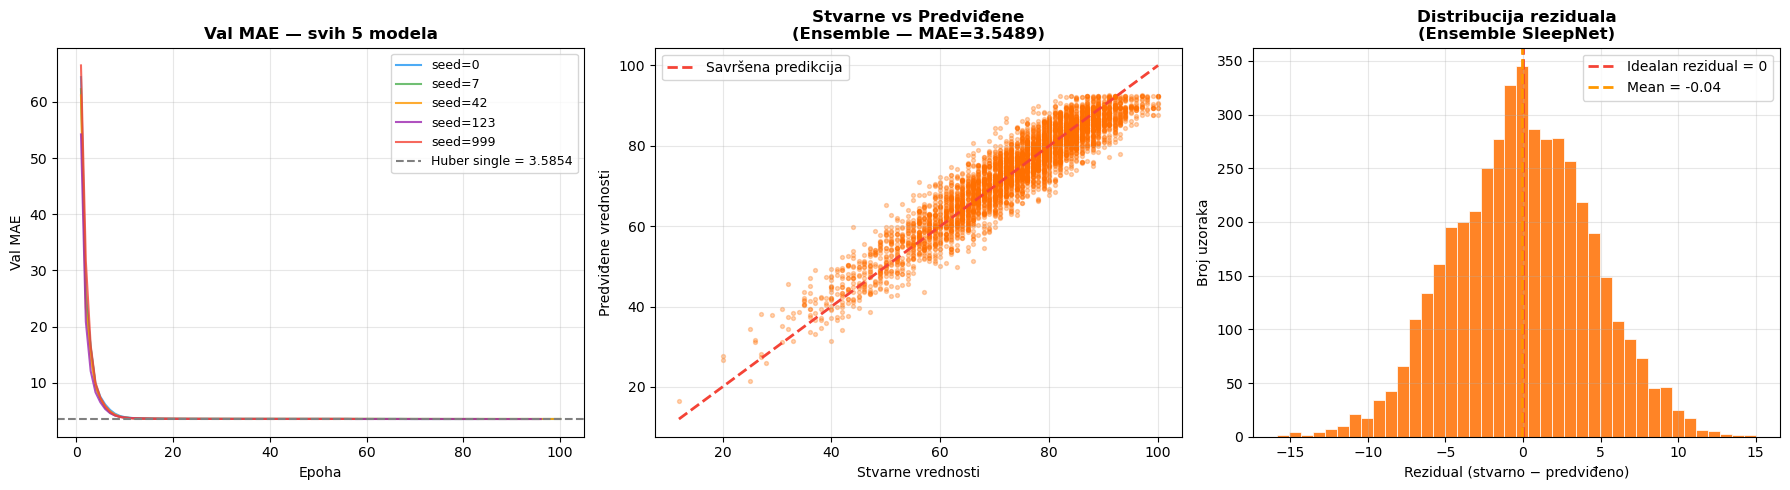

In [63]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Krive treninga svih 5 modela ---
colors_ens = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
for i, (hist, seed) in enumerate(zip(ensemble_histories, SEEDS)):
    ep = range(1, len(hist.history['val_mae']) + 1)
    axes[0].plot(ep, hist.history['val_mae'],
                 color=colors_ens[i], linewidth=1.5,
                 alpha=0.8, label=f'seed={seed}')
axes[0].axhline(y=test_mae_huber, color='gray', linestyle='--',
                linewidth=1.5, label=f'Huber single = {test_mae_huber:.4f}')
axes[0].set_title('Val MAE — svih 5 modela', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('Val MAE')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- Scatter: Stvarne vs Predviđene (ensemble) ---
axes[1].scatter(y_test, y_pred_ensemble, alpha=0.3, s=8, color='#FF6F00')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#F44336', linewidth=2, linestyle='--', label='Savršena predikcija')
axes[1].set_title(f'Stvarne vs Predviđene\n(Ensemble — MAE={test_mae_ensemble:.4f})',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Stvarne vrednosti')
axes[1].set_ylabel('Predviđene vrednosti')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# --- Distribucija reziduala ---
residuals_ens = y_test - y_pred_ensemble
axes[2].hist(residuals_ens, bins=40, color='#FF6F00',
             edgecolor='white', linewidth=0.6, alpha=0.85)
axes[2].axvline(x=0, color='#F44336', linewidth=2,
                linestyle='--', label='Idealan rezidual = 0')
axes[2].axvline(x=residuals_ens.mean(), color='#FF9800', linewidth=2,
                linestyle='--', label=f'Mean = {residuals_ens.mean():.2f}')
axes[2].set_title('Distribucija reziduala\n(Ensemble SleepNet)',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Rezidual (stvarno − predviđeno)')
axes[2].set_ylabel('Broj uzoraka')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [64]:

print("=" * 75)
print("POREĐENJE SVIH MODELA — Test set")
print("=" * 75)
print(f"{'Model':<26} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'Epohe':>7} {'Loss':>8} {'Batch':>6}")
print("-" * 75)
print(f"{'Mean Predictor':<26} {mae_baseline:>8.4f} {rmse_baseline:>8.4f} {r2_baseline:>8.4f} {'—':>7} {'—':>8} {'—':>6}")
print(f"{'Baseline SleepNet':<26} {test_mae:>8.4f} {test_rmse:>8.4f} {test_r2:>8.4f} {len(history.history['loss']):>7} {'MSE':>8} {'256':>6}")
print(f"{'Deep SleepNet v1':<26} {test_mae_f:>8.4f} {test_rmse_f:>8.4f} {test_r2_f:>8.4f} {len(history_deep.history['loss']):>7} {'MSE':>8} {'256':>6}")
print(f"{'ResNet SleepNet':<26} {test_mae_res:>8.4f} {test_rmse_res:>8.4f} {test_r2_res:>8.4f} {len(history_resnet.history['loss']):>7} {'MSE':>8} {'256':>6}")
print(f"{'Huber SleepNet':<26} {test_mae_huber:>8.4f} {test_rmse_huber:>8.4f} {test_r2_huber:>8.4f} {len(history_huber.history['loss']):>7} {'Huber':>8} {'256':>6}")
print(f"{'AdamW SleepNet':<26} {test_mae_adamw:>8.4f} {test_rmse_adamw:>8.4f} {test_r2_adamw:>8.4f} {len(history_adamw.history['loss']):>7} {'MSE':>8} {'64':>6}")
print(f"{'Ensemble SleepNet (x5)':<26} {test_mae_ensemble:>8.4f} {test_rmse_ensemble:>8.4f} {test_r2_ensemble:>8.4f} {'5×~':>7} {'Huber':>8} {'256':>6}")
print("=" * 75)

all_maes = {
    'Baseline SleepNet':   test_mae,
    'Deep SleepNet v1':   test_mae_f,
    'ResNet SleepNet':     test_mae_res,
    'Huber SleepNet':      test_mae_huber,
    'AdamW SleepNet':      test_mae_adamw,
    'Ensemble SleepNet':   test_mae_ensemble,
}
best_name = min(all_maes, key=all_maes.get)
best_val  = all_maes[best_name]
print(f"\nNajbolji model: {best_name}  →  MAE = {best_val:.4f}")
print(f"Poboljšanje vs Baseline SleepNet: {test_mae - best_val:+.4f}  "
      f"({(test_mae - best_val) / test_mae * 100:+.2f}%)")


POREĐENJE SVIH MODELA — Test set
Model                           MAE     RMSE       R²   Epohe     Loss  Batch
---------------------------------------------------------------------------
Mean Predictor              10.3249  12.9558  -0.0001       —        —      —
Baseline SleepNet            3.5502   4.4476   0.8821     100      MSE    256
Deep SleepNet v1             3.5689   4.4791   0.8807      42      MSE    256
ResNet SleepNet              3.6131   4.5397   0.8772      34      MSE    256
Huber SleepNet               3.5854   4.4829   0.8803      52    Huber    256
AdamW SleepNet               3.5575   4.4564   0.8817     100      MSE     64
Ensemble SleepNet (x5)       3.5489   4.4480   0.8821     5×~    Huber    256

Najbolji model: Ensemble SleepNet  →  MAE = 3.5489
Poboljšanje vs Baseline SleepNet: +0.0013  (+0.04%)
